# EZ-STANCE Mixed — vLLM Models vs Paper Baselines

Evaluates vLLM models on the **EZ-STANCE Subtask A mixed test set** (7,798 documents, 3 classes: FAVOR / AGAINST / NONE).
Both noun-phrase and claim targets, spanning 8 domains.

**Paper baselines** from Table 7 of Zhao & Caragea (ACL 2024):
Trained on mixed targets, evaluated on mixed test set (M→M column).
Best reported model: **BART-MNLI-eₚ = 0.812** (macro F1).

> Per-class baseline numbers for this M→M split are not reported in the paper; class-level reference lines are omitted.

## Step 1: Imports

In [260]:
import os
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

## Step 2: Config

In [261]:
# ── Paths ─────────────────────────────────────────────────────────────────
_rd = [Path("../data_out/stance/ezstance_test_mixed"), Path("data_out/stance/ezstance_test_mixed")]
RESULTS_DIR = next(p for p in _rd if p.exists())
print("RESULTS_DIR:", RESULTS_DIR.resolve())

_gd = [Path("../data_in/ezstance/ezstance_test_mixed.csv"), Path("data_in/ezstance/ezstance_test_mixed.csv")]
GOLD_CSV = next(p for p in _gd if p.exists())
print("GOLD_CSV:   ", GOLD_CSV.resolve())

# Both vLLM and GPT results live in RESULTS_DIR; prefixes differ by dataset tag
VLLM_PREFIX = "GenAIStanceOneShot_7798_ezstance_mixed_"
GPT_PREFIX  = "GenAIStanceOneShot_7798_ezstance_test_mixed_"
KNOWN_PREFIXES = [VLLM_PREFIX, GPT_PREFIX]

LABELS  = ["FAVOR", "AGAINST", "NONE"]
CLASSES = LABELS

PROMPT_ORDER = [
    "default_no_label_definitions",
    "default",
    "task_definition",
    "question",
    "cot",
    "task_definition_scale",
    "few_shot_3",
    "few_shot_6",
    "few_shot_9",
    "few_shot_12",
    "few_shot_15",
]

PROMPT_LABELS_CHART = {
    "default_no_label_definitions": "No-def",
    "default":                      "Default",
    "task_definition":              "Task-def",
    "question":                     "Question",
    "cot":                          "CoT",
    "task_definition_scale":        "Scale",
    "few_shot_3":  "3R",
    "few_shot_6":  "6R",
    "few_shot_9":  "9R",
    "few_shot_12": "12R",
    "few_shot_15": "15R",
}

# ── Model ordering: GPT first, then open models by size descending ─────────
MODEL_ORDER = [
    # Proprietary
    "gpt-5.2",
    "gpt-5-mini",
    # 14B
    "DeepSeek-R1-Distill-Qwen-14B",
    "Qwen3-14B",
    "phi-4",
    # 8B
    "Qwen3-8B",
    "DeepSeek-R1-Distill-Llama-8B",
    "Llama-3.1-8B-Instruct",
    # 4B
    "Qwen3-4B",
    "Qwen3-4B-Instruct-2507",
    "Nemotron-Mini-4B-Instruct",
    # 3.8B
    "phi-4-mini-instruct",
    # 1.7B
    "Qwen3-1.7B",
]

def _ordered_models(df_or_series, col="model"):
    """Return MODEL_ORDER entries that are present in df_or_series[col]."""
    if hasattr(df_or_series, "unique"):
        vals = set(df_or_series.unique())
    else:
        vals = set(df_or_series[col].apply(
            lambda m: m.split("/")[-1] if "/" in m else m
        ).unique())
    return [m for m in MODEL_ORDER if m in vals]

# Paper baselines — Table 7, M→M column (Zhao & Caragea, ACL 2024)
PAPER_BASELINES = OrderedDict([
    ("BiCE",           0.468),
    ("Cross-Net",      0.518),
    ("TGA-Net",        0.590),
    ("LLaMA2 (ZS)",    0.404),
    ("ChatGPT (ZS)",   0.499),
    ("RoBERTa",        0.784),
    ("RoBERTa-MNLI",   0.797),
    ("RoBERTa-MNLI_p", 0.799),
    ("BART-MNLI",      0.664),
    ("BART-MNLI-e",    0.810),
    ("BART-MNLI-ep",   0.812),
])

BEST_PAPER_F3 = PAPER_BASELINES["BART-MNLI-ep"]
CHATGPT_F3    = PAPER_BASELINES["ChatGPT (ZS)"]

GOLD_DIST = {"FAVOR": 2669/7798, "AGAINST": 2476/7798, "NONE": 2653/7798}

CLASS_COLORS = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}

DOMAIN_NAMES = {
    "CE": "Covid\nEpidemic", "WE": "World\nEvents",
    "EdC": "Educ &\nCulture", "EnC": "Entertain &\nConsumption",
    "S": "Sports", "R": "Rights", "EP": "Environ\nProtect", "P": "Politics",
}
DOMAIN_ORDER = ["CE", "WE", "EdC", "EnC", "S", "R", "EP", "P"]

CANON_MAP = {"PRO": "FAVOR", "NEUTRAL": "NONE", "UNCLEAR": "NONE", "UNRELATED": "NONE"}

def canonicalize(s):
    s = str(s).upper().strip()
    return CANON_MAP.get(s, s)

def extract_model_prompt(folder):
    for pfx in KNOWN_PREFIXES:
        if folder.startswith(pfx):
            stem  = folder[len(pfx):]
            parts = stem.rsplit("_equal_", 1)
            if len(parts) == 2:
                return parts[0], parts[1]
    return None, None

print("Best paper F3 (BART-MNLI-ep, M→M):", BEST_PAPER_F3)

RESULTS_DIR: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_out/stance/ezstance_test_mixed
GOLD_CSV:    /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_in/ezstance/ezstance_test_mixed.csv
Best paper F3 (BART-MNLI-ep, M→M): 0.812


## Step 3: Load LLM Results

In [262]:
llm_rows = []

for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_7798"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue

    df = pd.read_csv(csv_path)
    df["original_stance"] = df["original_stance"].astype(str).str.upper().str.strip()
    df = df[df["original_stance"].isin(CLASSES)].copy()
    df["predicted_stance"] = df["predicted_stance"].apply(
        lambda x: canonicalize(x) if pd.notna(x) else None
    )
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100:
        print(f"  SKIP {folder}: only {len(df)} valid rows")
        continue

    yt = df["original_stance"].tolist()
    yp = df["predicted_stance"].tolist()
    prec, rec, f1, _ = precision_recall_fscore_support(
        yt, yp, labels=CLASSES, zero_division=0
    )
    macro_f1 = f1.mean()
    vc = pd.Series(yp).value_counts()

    llm_rows.append({
        "model":           model,
        "prompt":          prompt,
        "3class_macro_f1": macro_f1,
        "f_favor":         f1[0],
        "f_against":       f1[1],
        "f_none":          f1[2],
        "p_favor":         prec[0],
        "p_against":       prec[1],
        "p_none":          prec[2],
        "r_favor":         rec[0],
        "r_against":       rec[1],
        "r_none":          rec[2],
        "pred_favor":      vc.get("FAVOR",   0),
        "pred_against":    vc.get("AGAINST", 0),
        "pred_none":       vc.get("NONE",    0),
        "n_valid":         len(df),
    })

llm_df = pd.DataFrame(llm_rows)
print(f"Total experiment rows: {len(llm_df)}")
print(f"Models:  {sorted(llm_df['model'].unique())}")
print(f"Prompts: {sorted(llm_df['prompt'].unique())}")

Total experiment rows: 143
Models:  ['DeepSeek-R1-Distill-Llama-8B', 'DeepSeek-R1-Distill-Qwen-14B', 'Llama-3.1-8B-Instruct', 'Nemotron-Mini-4B-Instruct', 'Qwen3-1.7B', 'Qwen3-14B', 'Qwen3-4B', 'Qwen3-4B-Instruct-2507', 'Qwen3-8B', 'gpt-5-mini', 'gpt-5.2', 'phi-4', 'phi-4-mini-instruct']
Prompts: ['cot', 'default', 'default_no_label_definitions', 'few_shot_12', 'few_shot_15', 'few_shot_3', 'few_shot_6', 'few_shot_9', 'question', 'task_definition', 'task_definition_scale']


## Step 3b: Training & Test Label Distribution

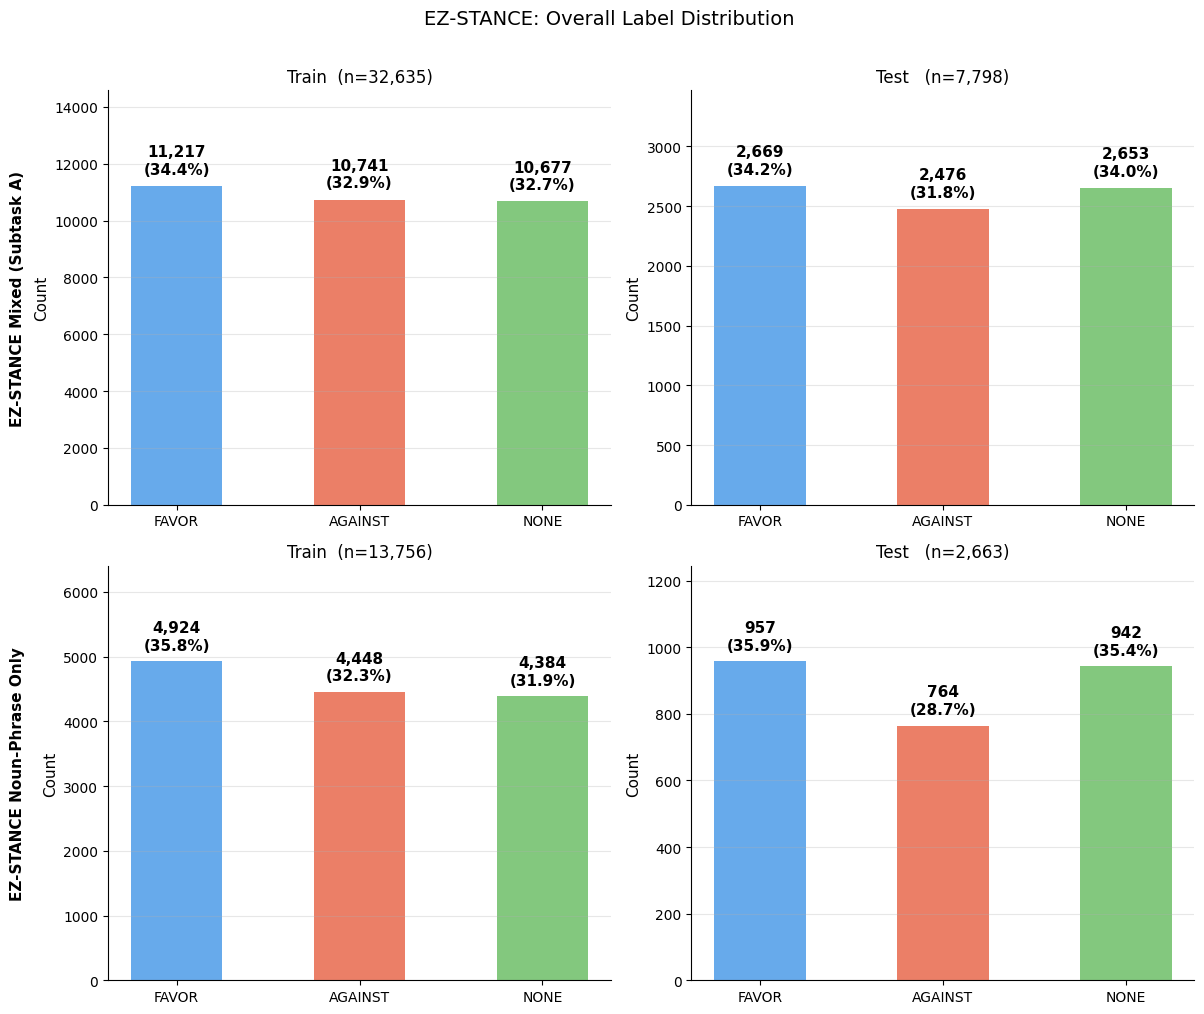

In [263]:
# ── Resolve data paths ────────────────────────────────────────────────────────
def _find(rel, alt):
    return Path(rel) if Path(rel).exists() else Path(alt)

MIXED_TRAIN_CSV = _find("../ezstance/subtaskA/mixed/raw_train_all_onecol.csv",
                            "ezstance/subtaskA/mixed/raw_train_all_onecol.csv")
NP_TRAIN_CSV    = _find("../ezstance/subtaskA/noun_phrase/raw_train_all_onecol.csv",
                            "ezstance/subtaskA/noun_phrase/raw_train_all_onecol.csv")
NP_TEST_CSV     = _find("../data_in/ezstance/ezstance_test.csv", "data_in/ezstance/ezstance_test.csv")

mixed_train = pd.read_csv(MIXED_TRAIN_CSV)
mixed_test  = pd.read_csv(GOLD_CSV)
np_train    = pd.read_csv(NP_TRAIN_CSV)
np_test     = pd.read_csv(NP_TEST_CSV)

COLORS = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}

def label_counts(df, col):
    vc = df[col].str.upper().str.strip().value_counts()
    return {lbl: vc.get(lbl, 0) for lbl in LABELS}

splits = [
    # (ax row, ax col, counts_dict, title)
    (0, 0, label_counts(mixed_train, "Stance 1"),              f"Train  (n={len(mixed_train):,})"),
    (0, 1, label_counts(mixed_test,  "stance_label_original"), f"Test   (n={len(mixed_test):,})"),
    (1, 0, label_counts(np_train,    "Stance 1"),              f"Train  (n={len(np_train):,})"),
    (1, 1, label_counts(np_test,     "stance_label_original"), f"Test   (n={len(np_test):,})"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row, col, counts, title in splits:
    ax     = axes[row][col]
    total  = sum(counts.values())
    values = [counts[l] for l in LABELS]
    colors = [COLORS[l] for l in LABELS]
    bars   = ax.bar(LABELS, values, color=colors, alpha=0.85, width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total * 0.01,
                f"{val:,}\n({val/total:.1%})",
                ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_ylim(0, max(values) * 1.3)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

# Row labels
for row_idx, label in enumerate(["EZ-STANCE Mixed (Subtask A)", "EZ-STANCE Noun-Phrase Only"]):
    axes[row_idx][0].annotate(label, xy=(-0.18, 0.5),
                              xycoords="axes fraction",
                              fontsize=11, fontweight="bold",
                              rotation=90, va="center", ha="center")

fig.suptitle("EZ-STANCE: Overall Label Distribution", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Step 4: Pooled Metrics

In [264]:
best_idx  = llm_df["3class_macro_f1"].idxmax()
worst_idx = llm_df["3class_macro_f1"].idxmin()

print("=== Pooled 3-class Macro F1 (all model×prompt) ===")
print(f"  Mean:  {llm_df['3class_macro_f1'].mean():.4f}")
print(f"  Best:  {llm_df.loc[best_idx, '3class_macro_f1']:.4f}  "
      f"({llm_df.loc[best_idx, 'model']} | {llm_df.loc[best_idx, 'prompt']})")
print(f"  Worst: {llm_df.loc[worst_idx, '3class_macro_f1']:.4f}  "
      f"({llm_df.loc[worst_idx, 'model']} | {llm_df.loc[worst_idx, 'prompt']})")
print()
print(f"Paper best (BART-MNLI-ep, M→M): {BEST_PAPER_F3:.4f}")
print(f"Paper ChatGPT (zero-shot):       {CHATGPT_F3:.4f}")

=== Pooled 3-class Macro F1 (all model×prompt) ===
  Mean:  0.4822
  Best:  0.6034  (gpt-5.2 | default)
  Worst: 0.1700  (Nemotron-Mini-4B-Instruct | task_definition_scale)

Paper best (BART-MNLI-ep, M→M): 0.8120
Paper ChatGPT (zero-shot):       0.4990


## Step 5: Chart — 3-class Macro F1 vs Paper Baselines

Baseline = EZ-STANCE paper Table 7 (M→M, trained+tested on mixed targets).
Fine-tuned best: **BART-MNLI-eₚ = 0.812**. Zero-shot LLMs from paper: ChatGPT 0.499, LLaMA2 0.404.

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_5452/3719397321.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab20", max(len(models), 2))


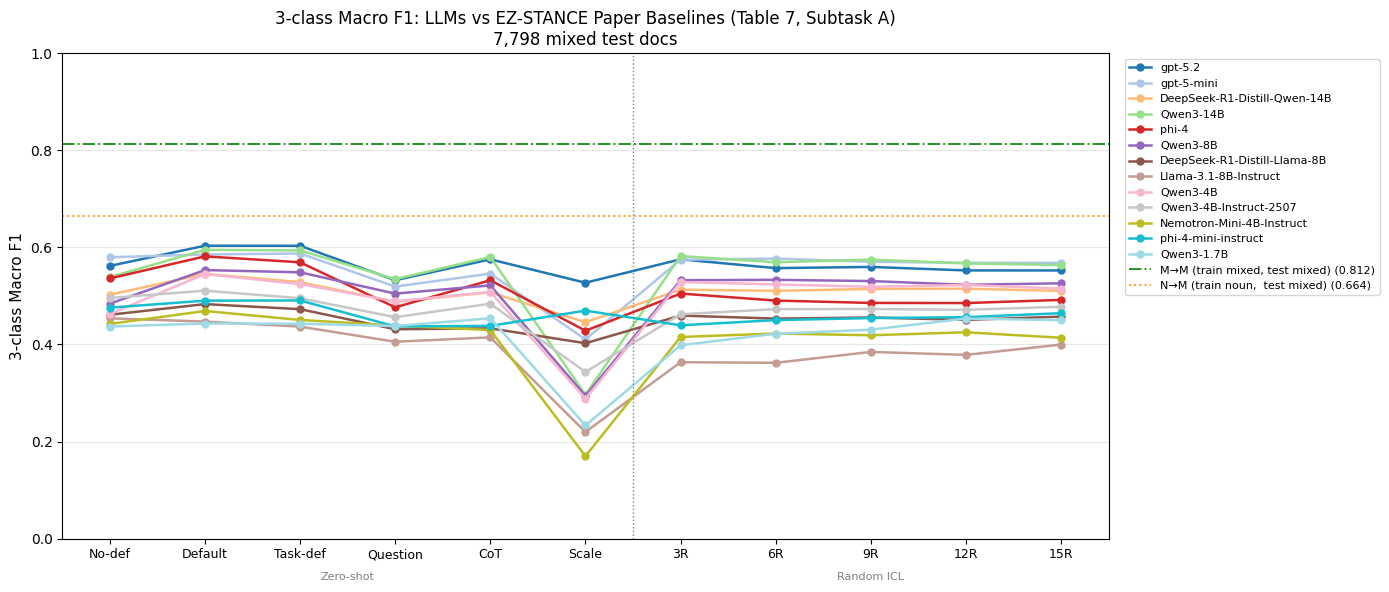

In [265]:
available_prompts = [p for p in PROMPT_ORDER if p in llm_df["prompt"].unique()]
x_labels = [PROMPT_LABELS_CHART[p] for p in available_prompts]
x_pos    = list(range(len(available_prompts)))

models = _ordered_models(llm_df)
cmap   = plt.cm.get_cmap("tab20", max(len(models), 2))

fig, ax = plt.subplots(figsize=(max(14, len(available_prompts) * 1.1), 6))

for i, model in enumerate(models):
    mdf = llm_df[llm_df["model"] == model].set_index("prompt")
    y = [mdf.loc[p, "3class_macro_f1"] if p in mdf.index else float("nan")
         for p in available_prompts]
    short = model.split("/")[-1] if "/" in model else model
    ax.plot(x_pos, y, marker="o", linewidth=1.8, markersize=5,
            label=short, color=cmap(i))

# Best supervised baseline per training/testing configuration — Table 7, Subtask A
key_baselines = [
    ("M\u2192M (train mixed, test mixed)", 0.812, "green",      "-."),
    ("N\u2192M (train noun,  test mixed)", 0.664, "darkorange", ":"),
]
for name, val, col, ls in key_baselines:
    ax.axhline(val, color=col, linestyle=ls, linewidth=1.4, alpha=0.85,
               label=f"{name} ({val:.3f})")

if "task_definition_scale" in available_prompts and "few_shot_3" in available_prompts:
    sx = (available_prompts.index("task_definition_scale") +
          available_prompts.index("few_shot_3")) / 2
    ax.axvline(sx, color="grey", linestyle=":", linewidth=1)
    for j, lbl in enumerate(["Zero-shot", "Random ICL"]):
        mid = ([-0.5, sx][j] + [sx, len(available_prompts) - 0.5][j]) / 2
        ax.text(mid, -0.085, lbl, ha="center", fontsize=8, color="grey",
                transform=ax.get_xaxis_transform())

ax.set_ylim(0, 1)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel("3-class Macro F1", fontsize=11)
ax.set_title(
    "3-class Macro F1: LLMs vs EZ-STANCE Paper Baselines (Table 7, Subtask A)\n7,798 mixed test docs",
    fontsize=12,
)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Step 6: Numerical Tables

**Table I** — per-model summary: mean / best / std F3 across all prompts.
**Table II** — per-model × prompt: F3 and per-class F1.

In [266]:
summary = (
    llm_df.groupby("model")
    .agg(
        mean_f3=("3class_macro_f1", "mean"),
        best_f3=("3class_macro_f1", "max"),
        std_f3 =("3class_macro_f1", "std"),
    )
    .reset_index()
    .sort_values("mean_f3", ascending=False)
)
summary["model_short"] = summary["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)

print("=== Table I: Per-model Summary ===")
print(f"{'Model':<42} {'mean_F3':>8} {'best_F3':>8} {'std_F3':>8}")
print("-" * 72)
for _, r in summary.iterrows():
    print(f"{r['model_short']:<42} {r['mean_f3']:>8.4f} {r['best_f3']:>8.4f} {r['std_f3']:>8.4f}")
print()
print(f"Paper best (BART-MNLI-ep, M→M):   {BEST_PAPER_F3:.4f}")
print(f"Paper ChatGPT (zero-shot, M→N):    {CHATGPT_F3:.4f}")

print("\n=== Table II: Per-model × Prompt ===")
tbl = llm_df.copy()
tbl["prompt_rank"]  = tbl["prompt"].map({p: i for i, p in enumerate(PROMPT_ORDER)})
tbl["model_short"]  = tbl["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)
tbl = tbl.sort_values(["model_short", "prompt_rank"])
cols = ["model_short", "prompt", "3class_macro_f1", "f_favor", "f_against", "f_none"]
print(tbl[cols].to_string(index=False, float_format="{:.4f}".format))

=== Table I: Per-model Summary ===
Model                                       mean_F3  best_F3   std_F3
------------------------------------------------------------------------
gpt-5.2                                      0.5637   0.6034   0.0246
gpt-5-mini                                   0.5533   0.5874   0.0512
Qwen3-14B                                    0.5451   0.5949   0.0846
phi-4                                        0.5074   0.5815   0.0441
DeepSeek-R1-Distill-Qwen-14B                 0.5073   0.5455   0.0250
Qwen3-8B                                     0.5047   0.5532   0.0723
Qwen3-4B                                     0.4933   0.5451   0.0714
Qwen3-4B-Instruct-2507                       0.4675   0.5108   0.0441
phi-4-mini-instruct                          0.4606   0.4907   0.0194
DeepSeek-R1-Distill-Llama-8B                 0.4510   0.4832   0.0219
Qwen3-1.7B                                   0.4184   0.4540   0.0634
Nemotron-Mini-4B-Instruct                    0.4088 

## Step 7: Per-class Precision / Recall / F1 — by Prompt

3 × 3 grid: **rows** = class (FAVOR, AGAINST, NONE), **columns** = metric (Precision, Recall, F1).
No class-level paper baseline available for this M→M setting.

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_5452/162732542.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab20", len(models))


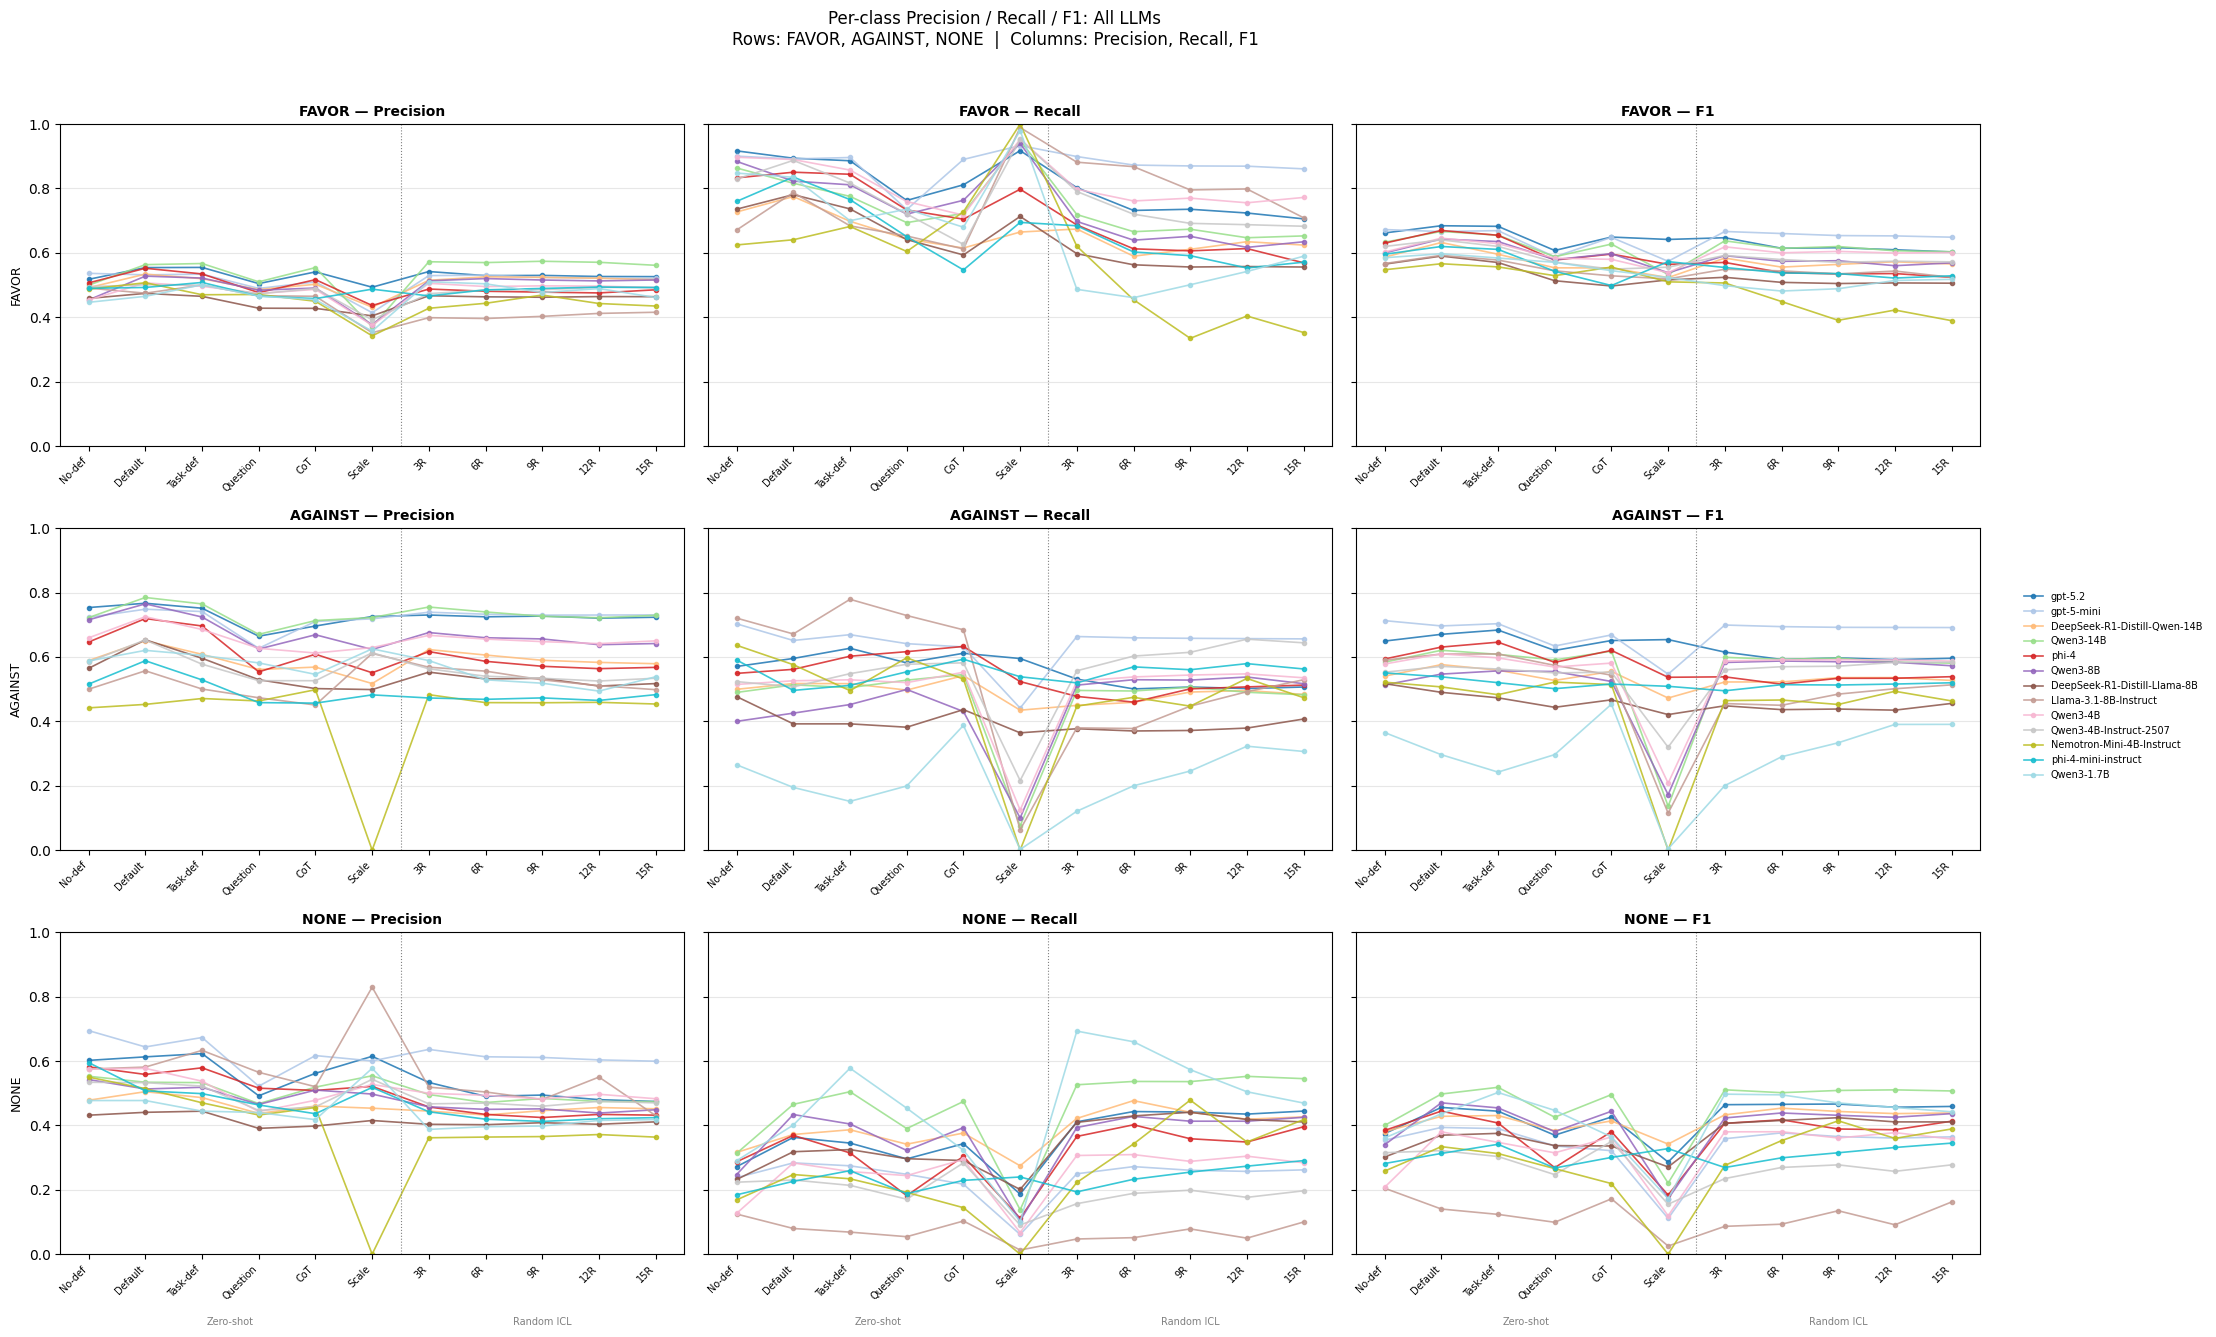

In [267]:
METRICS = [("p", "Precision"), ("r", "Recall"), ("f", "F1")]

available_prompts = [p for p in PROMPT_ORDER if p in llm_df["prompt"].unique()]
x_pos    = list(range(len(available_prompts)))
x_labels = [PROMPT_LABELS_CHART[p] for p in available_prompts]

models = _ordered_models(llm_df)
cmap   = plt.cm.get_cmap("tab20", len(models))

fig, axes = plt.subplots(3, 3, figsize=(20, 13), sharey="row")

for row_idx, cls in enumerate(CLASSES):
    for col_idx, (metric_key, metric_label) in enumerate(METRICS):
        ax = axes[row_idx][col_idx]
        col_name = f"{metric_key}_{cls.lower()}"

        for i, model in enumerate(models):
            mdf   = llm_df[llm_df["model"] == model].set_index("prompt")
            y     = [mdf.loc[p, col_name] if p in mdf.index else float("nan")
                     for p in available_prompts]
            short = model.split("/")[-1] if "/" in model else model
            ax.plot(x_pos, y, marker="o", linewidth=1.2, markersize=3,
                    label=short, color=cmap(i), alpha=0.85)

        # Zero-shot / Random ICL separator
        if "task_definition_scale" in available_prompts and "few_shot_3" in available_prompts:
            sx = (available_prompts.index("task_definition_scale") +
                  available_prompts.index("few_shot_3")) / 2
            ax.axvline(sx, color="grey", linestyle=":", linewidth=0.8)

        ax.set_ylim(0, 1)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=7, rotation=45, ha="right")
        ax.set_title(f"{cls} — {metric_label}", fontsize=10, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=9)

handles, leg_labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, leg_labels, bbox_to_anchor=(1.01, 0.5),
           loc="center left", fontsize=7, frameon=False)

# Group labels on bottom row
boundaries = [-0.5]
if "task_definition_scale" in available_prompts and "few_shot_3" in available_prompts:
    boundaries.append((available_prompts.index("task_definition_scale") +
                       available_prompts.index("few_shot_3")) / 2)
boundaries.append(len(available_prompts) - 0.5)
group_names = ["Zero-shot", "Random ICL"]
for col_idx in range(3):
    ax = axes[2][col_idx]
    for gi, glbl in enumerate(group_names):
        if gi < len(boundaries) - 1:
            mid = (boundaries[gi] + boundaries[gi + 1]) / 2
            ax.text(mid, -0.22, glbl, ha="center", fontsize=7, color="grey",
                    transform=ax.get_xaxis_transform())

fig.suptitle(
    "Per-class Precision / Recall / F1: All LLMs\n"
    "Rows: FAVOR, AGAINST, NONE  |  Columns: Precision, Recall, F1",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

## Step 8: Per-class F1 — Model Comparison (mean ± std across prompts)

Three panels (FAVOR / AGAINST / NONE). Bar = mean class F1 across all prompts. Error bar = std.
No class-level paper baseline available for M→M setting.

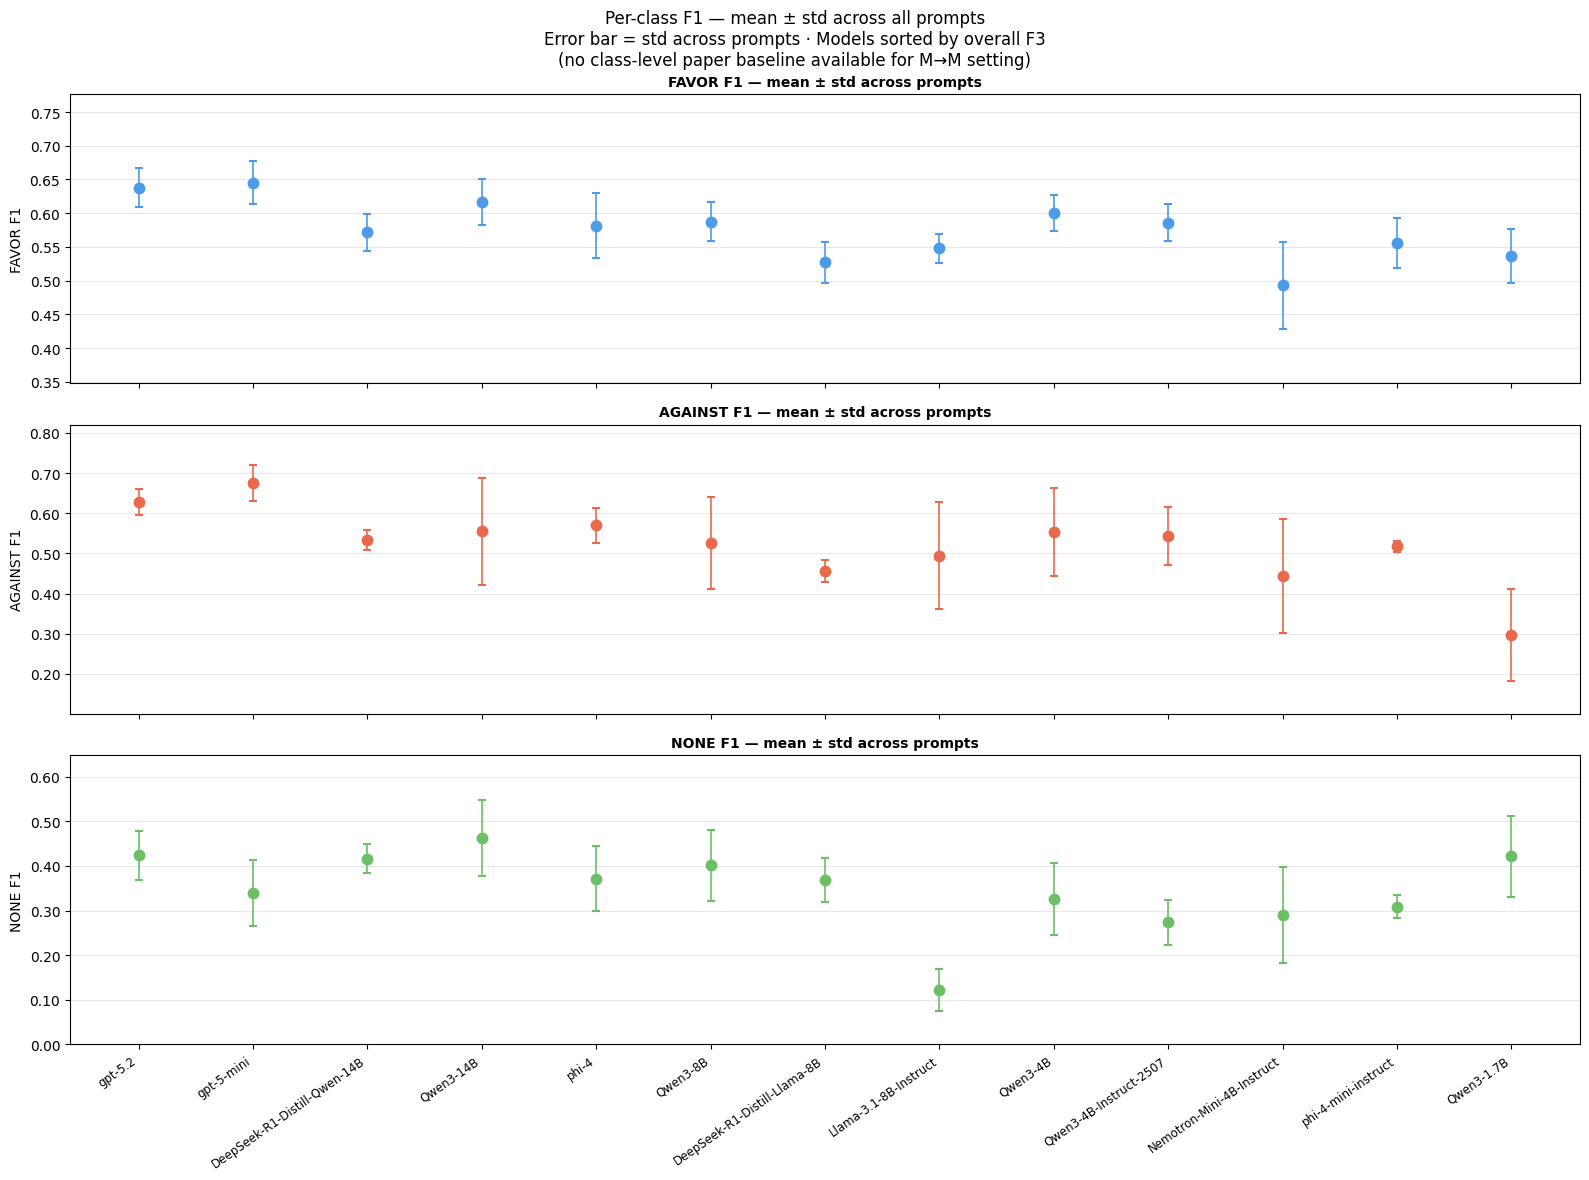

In [268]:
CLASS_COLS  = {"FAVOR": "f_favor", "AGAINST": "f_against", "NONE": "f_none"}
CLASS_COLOR = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C",   "NONE": "#6DBF67"}

model_order = _ordered_models(llm_df)
model_labels = [m.split("/")[-1] if "/" in m else m for m in model_order]
x = np.arange(len(model_order))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for row_idx, cls in enumerate(["FAVOR", "AGAINST", "NONE"]):
    ax    = axes[row_idx]
    col   = CLASS_COLS[cls]
    color = CLASS_COLOR[cls]

    means, stds = [], []
    for model in model_order:
        vals = llm_df[llm_df["model"] == model][col].values
        means.append(vals.mean())
        stds.append(vals.std())
    means = np.array(means)
    stds  = np.array(stds)

    ax.errorbar(x, means, yerr=stds, fmt="o", markersize=7,
                color=color, markeredgecolor=color, markeredgewidth=1.5,
                ecolor=color, elinewidth=1.2, capsize=3, zorder=3)

    ax.set_ylabel(f"{cls} F1", fontsize=10)
    ax.set_ylim(max(0, (means - stds).min() - 0.08), min(1, (means + stds).max() + 0.1))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.grid(axis="y", alpha=0.3)
    ax.set_title(f"{cls} F1 — mean ± std across prompts", fontsize=10, fontweight="bold")

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(model_labels, rotation=35, ha="right", fontsize=8.5)

fig.suptitle(
    "Per-class F1 — mean ± std across all prompts\n"
    "Error bar = std across prompts · Models sorted by overall F3\n"
    "(no class-level paper baseline available for M→M setting)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Step 9: Precision vs Recall Scatter — per class

Each dot = one model × prompt combination, coloured by model.
Grey curves = F1 iso-contours (0.2, 0.4, 0.6, 0.8). Dashed diagonal = P = R.
No paper-baseline stars (class-level not available for M→M).

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_5452/2174058824.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap        = plt.cm.get_cmap("tab20", len(models))


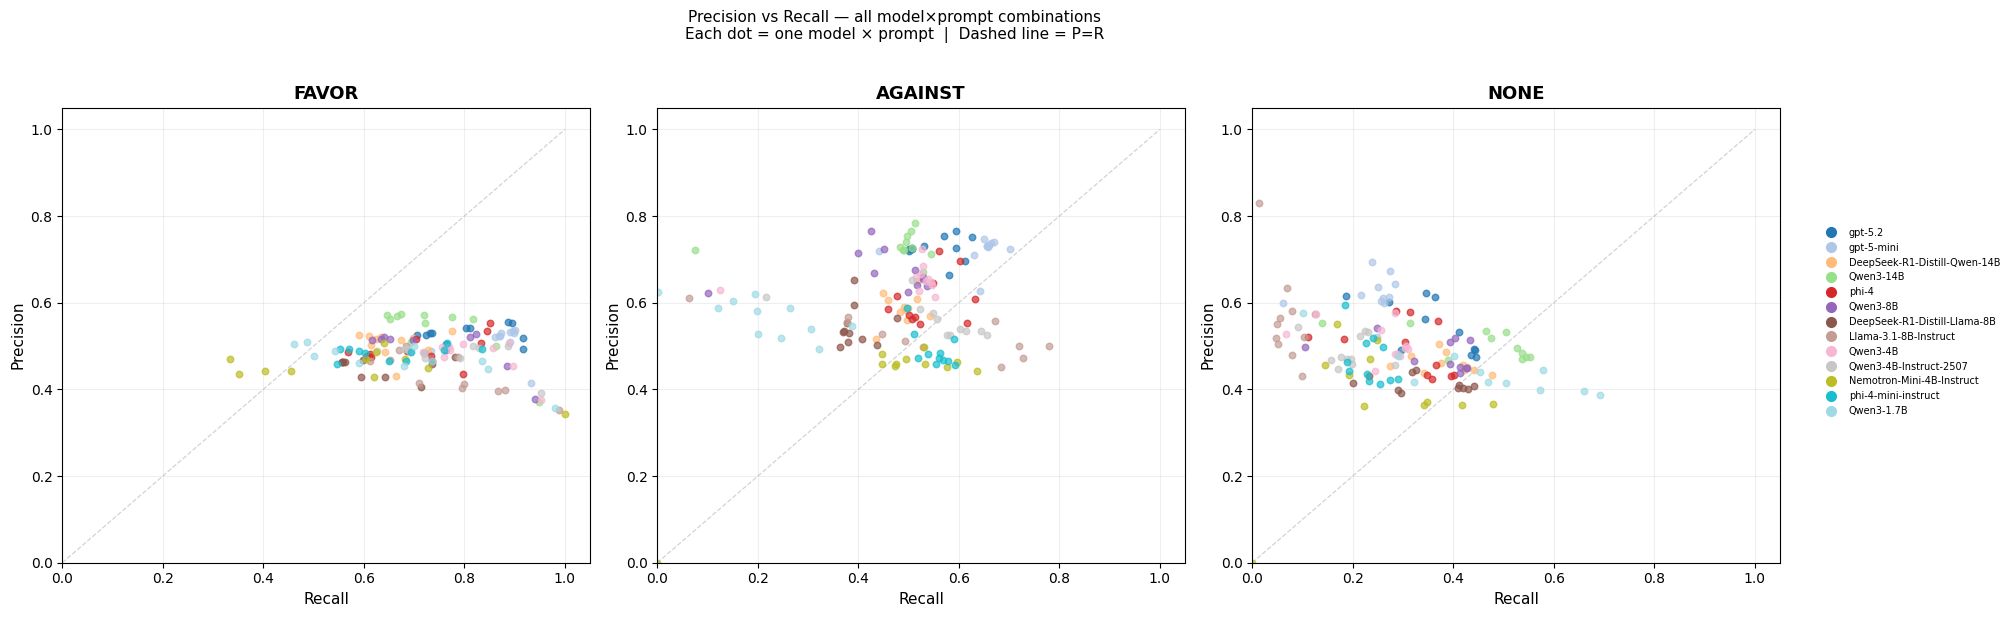

In [269]:
models      = _ordered_models(llm_df)
cmap        = plt.cm.get_cmap("tab20", len(models))
model_color = {m: cmap(i) for i, m in enumerate(models)}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for col_idx, cls in enumerate(CLASSES):
    ax    = axes[col_idx]
    p_col = f"p_{cls.lower()}"
    r_col = f"r_{cls.lower()}"

    # P = R diagonal
    ax.plot([0, 1], [0, 1], color="lightgrey", linestyle="--", linewidth=0.9, zorder=0)

    # LLM scatter — x=Recall, y=Precision (matches SemEval baseline convention)
    for model in models:
        mdf   = llm_df[llm_df["model"] == model]
        short = model.split("/")[-1] if "/" in model else model
        ax.scatter(mdf[r_col], mdf[p_col],
                   color=model_color[model], s=22, alpha=0.7, zorder=2, label=short)

    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall",    fontsize=11)
    ax.set_ylabel("Precision", fontsize=11)
    ax.set_title(cls, fontsize=13, fontweight="bold")
    ax.grid(alpha=0.2)

handles = [mlines.Line2D([], [], marker="o", linestyle="None",
                          color=model_color[m], markersize=7,
                          label=m.split("/")[-1] if "/" in m else m)
           for m in models]
fig.legend(handles=handles, bbox_to_anchor=(1.01, 0.5), loc="center left",
           fontsize=7, frameon=False)

fig.suptitle(
    "Precision vs Recall — all model×prompt combinations\n"
    "Each dot = one model × prompt  |  Dashed line = P=R",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

## Step 10: Predicted vs Gold Distribution — per class, per model across all prompts

Dots = per-prompt predicted fraction. Diamond = mean across prompts. Red line = gold test fraction.

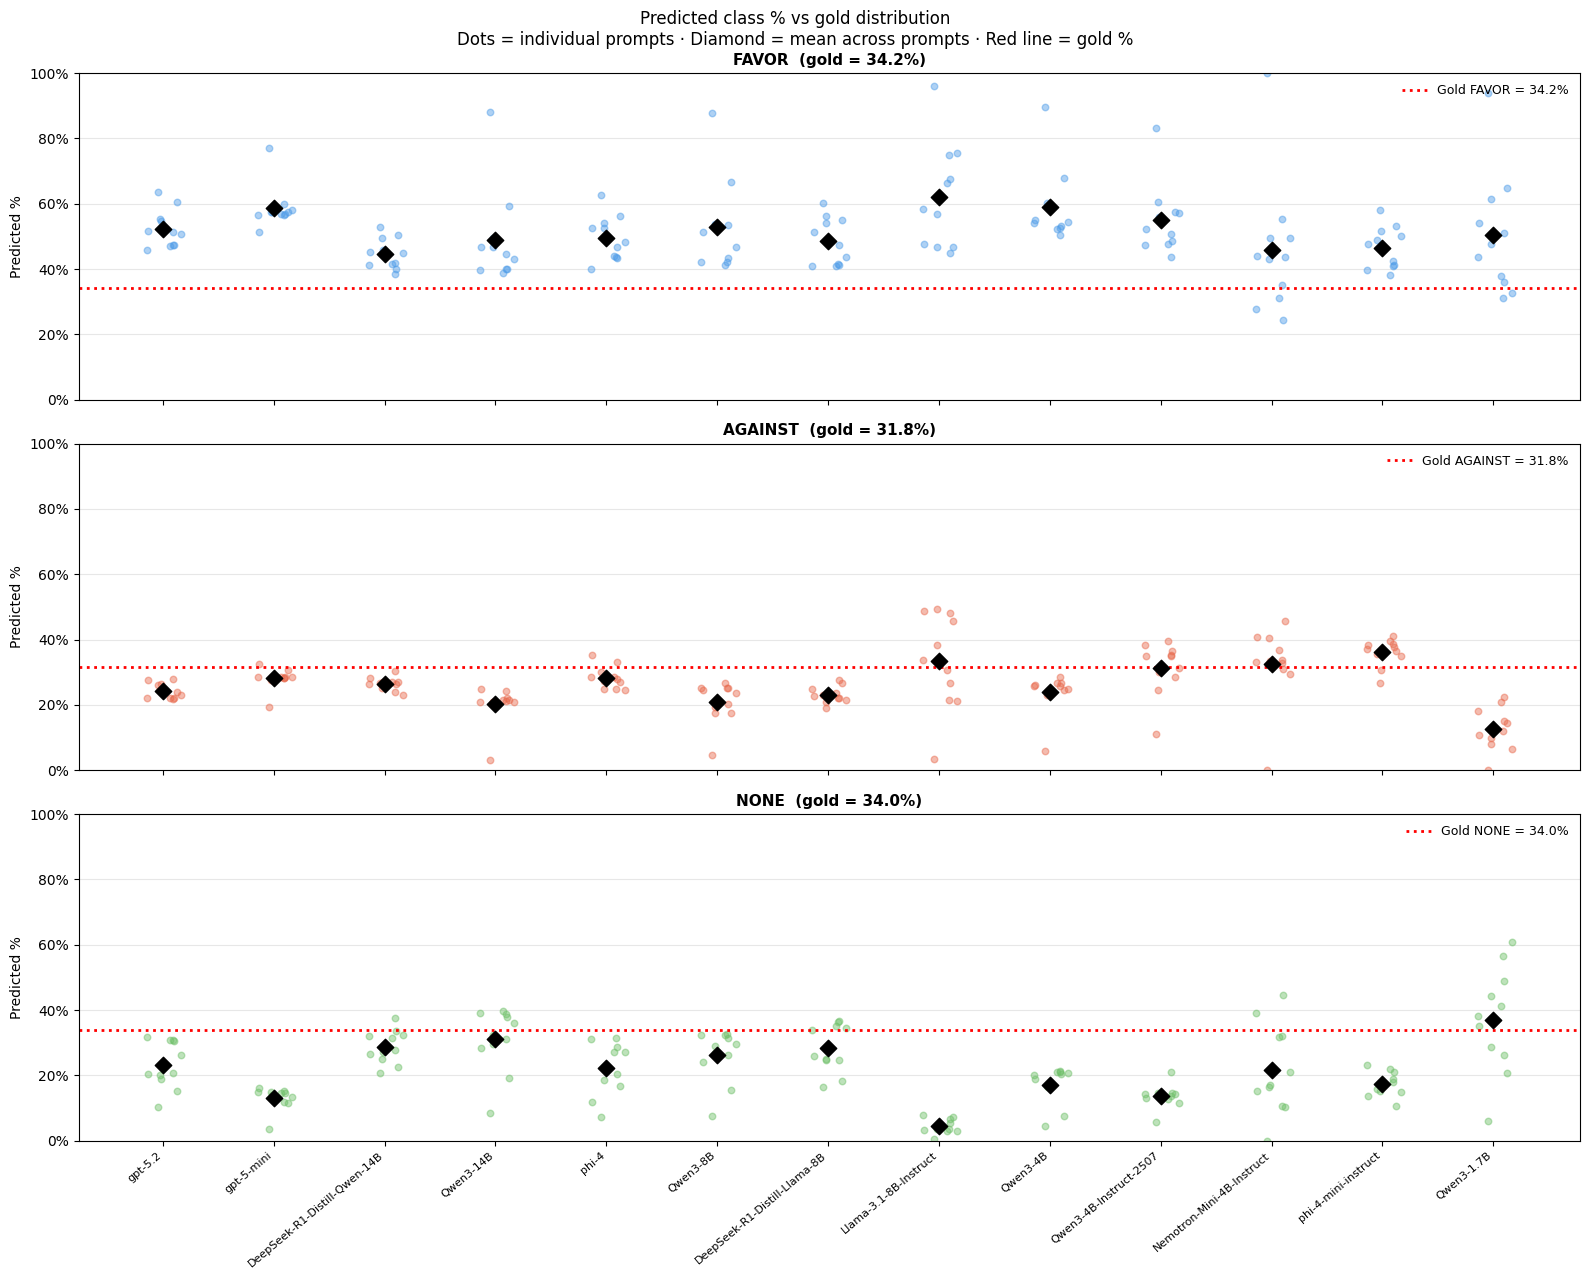

In [270]:
dist_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_7798"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue
    df = pd.read_csv(csv_path)
    df["predicted_stance"] = df["predicted_stance"].apply(
        lambda x: canonicalize(x) if pd.notna(x) else None
    )
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) == 0:
        continue
    vc = df["predicted_stance"].value_counts(normalize=True)
    dist_rows.append({
        "model": model, "prompt": prompt,
        "pred_favor":   vc.get("FAVOR",   0),
        "pred_against": vc.get("AGAINST", 0),
        "pred_none":    vc.get("NONE",    0),
        "model_short":  model.split("/")[-1] if "/" in model else model,
    })

dist_df = pd.DataFrame(dist_rows)

CLASS_COLS_D = {"FAVOR": "pred_favor", "AGAINST": "pred_against", "NONE": "pred_none"}
llm_models_sorted = _ordered_models(dist_df, "model_short")
x = np.arange(len(llm_models_sorted))
model_idx = {m: i for i, m in enumerate(llm_models_sorted)}

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

for row_idx, cls in enumerate(["FAVOR", "AGAINST", "NONE"]):
    ax       = axes[row_idx]
    col      = CLASS_COLS_D[cls]
    gold_pct = GOLD_DIST[cls]
    color    = CLASS_COLORS[cls]

    for model in llm_models_sorted:
        mdf = dist_df[dist_df["model_short"] == model]
        xi  = model_idx[model]
        jitter = (np.random.default_rng(42).random(len(mdf)) - 0.5) * 0.35
        ax.scatter(xi + jitter, mdf[col], alpha=0.45, s=22, color=color, zorder=2)
        ax.scatter(xi, mdf[col].mean(), marker="D", s=70, color="black", zorder=4)

    ax.axhline(gold_pct, color="red", linestyle=":", linewidth=2,
               label=f"Gold {cls} = {gold_pct:.1%}")

    ax.set_ylabel("Predicted %", fontsize=10)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_title(f"{cls}  (gold = {gold_pct:.1%})", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(llm_models_sorted, rotation=40, ha="right", fontsize=8)

fig.suptitle(
    "Predicted class % vs gold distribution\n"
    "Dots = individual prompts · Diamond = mean across prompts · Red line = gold %",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Step 11: Confusion Transition Analysis — Key Misclassifications

Six off-diagonal transitions: AGAINST→NONE, AGAINST→FAVOR, FAVOR→AGAINST, FAVOR→NONE, NONE→FAVOR, NONE→AGAINST.
**Table A** — per model, averaged across prompts. **Heatmap** — all model×prompt rows.

=== Table A: Confusion Transitions — per model (mean across all prompts) ===
Model                                   FAVOR→FAVOR   FAVOR→AGAINST      FAVOR→NONE   AGAINST→FAVOR AGAINST→AGAINST    AGAINST→NONE      NONE→FAVOR    NONE→AGAINST       NONE→NONE
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
gpt-5.2                                      80.8%            5.7%           13.5%           24.3%           55.7%           20.0%           49.9%           14.0%           36.2% 
gpt-5-mini                                   87.4%            6.3%            6.3%           27.0%           63.9%            9.1%           59.3%           16.9%           23.8% 
DeepSeek-R1-Distill-Qwen-14B                 66.0%           13.7%           20.3%           23.7%           49.0%           27.3%           43.1%           18.3%           38.6% 
Qwen3-14B              

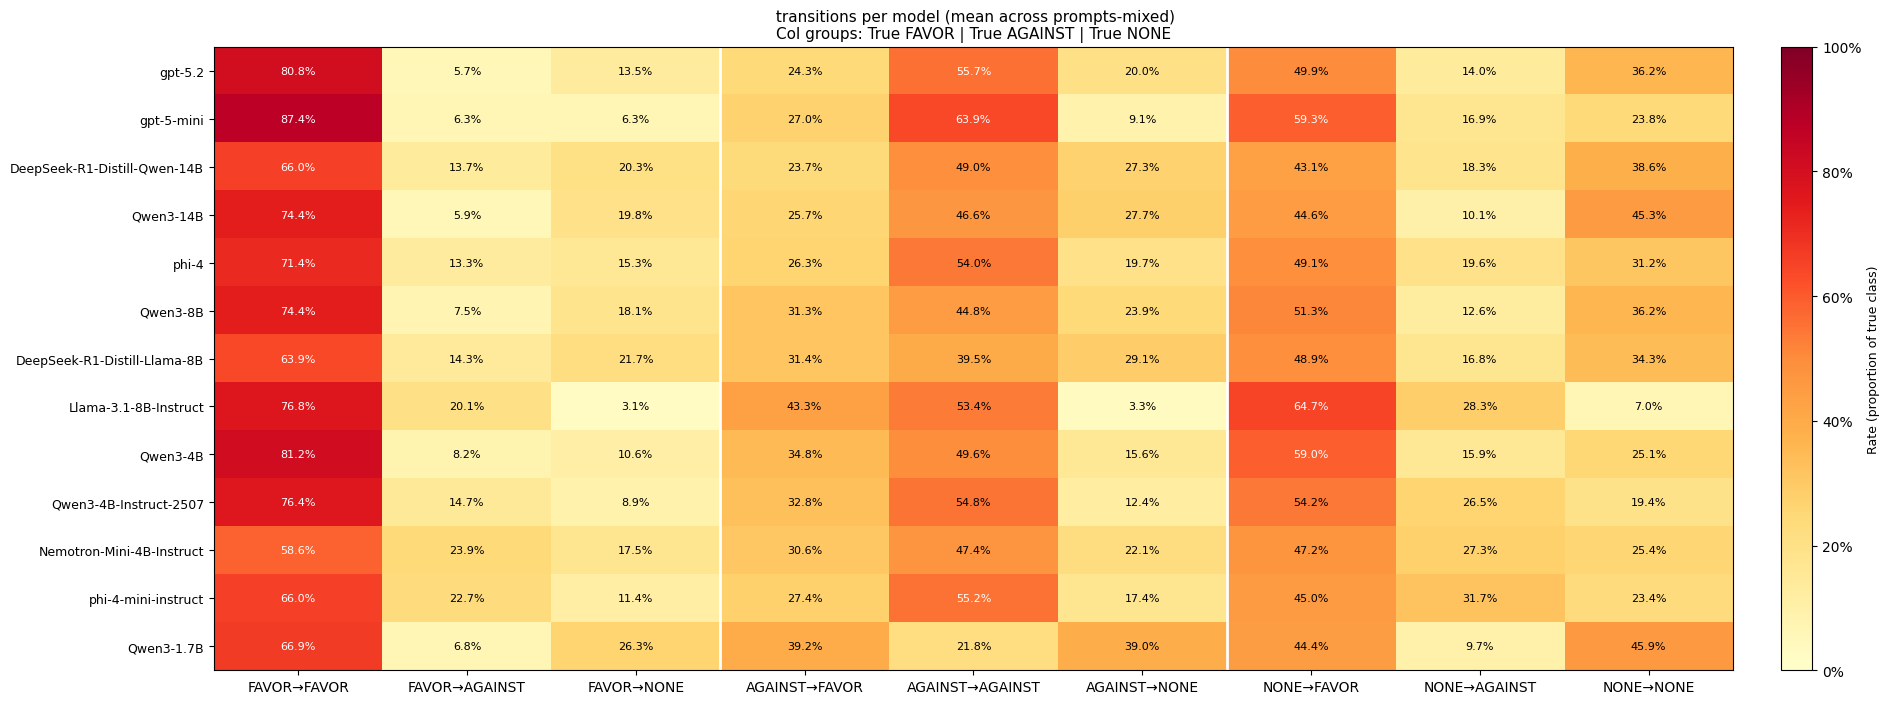


=== Table B: Confusion Transitions — per model × prompt ===
Model · Prompt                                       FAVOR→FAVOR   FAVOR→AGAINST      FAVOR→NONE   AGAINST→FAVOR AGAINST→AGAINST    AGAINST→NONE      NONE→FAVOR    NONE→AGAINST       NONE→NONE
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
DeepSeek-R1-Distill-Llama-8B · No-def                     73.6%           13.5%           12.9%           33.5%           47.7%           18.8%           56.1%           20.7%           23.2% 
DeepSeek-R1-Distill-Llama-8B · Default                    78.1%            7.0%           14.9%           33.6%           39.2%           27.2%           55.8%           12.4%           31.8% 
DeepSeek-R1-Distill-Llama-8B · Task-def                   73.7%           10.2%           16.2%           34.6%           39.2%           26.2%           53.0%        

In [271]:
KEY_TRANS = [
    "FAVOR→FAVOR",   "FAVOR→AGAINST",   "FAVOR→NONE",
    "AGAINST→FAVOR", "AGAINST→AGAINST", "AGAINST→NONE",
    "NONE→FAVOR",    "NONE→AGAINST",    "NONE→NONE",
]

cm_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_7798"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue

    df = pd.read_csv(csv_path)
    df["original_stance"]  = df["original_stance"].astype(str).str.upper().str.strip()
    df["predicted_stance"] = df["predicted_stance"].apply(
        lambda x: (lambda s: CANON_MAP.get(s, s))(str(x).upper().strip())
        if pd.notna(x) else None
    )
    df = df[df["original_stance"].isin(CLASSES) & df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100:
        continue

    yt, yp  = df["original_stance"].tolist(), df["predicted_stance"].tolist()
    cm      = confusion_matrix(yt, yp, labels=CLASSES).astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    short   = model.split("/")[-1] if "/" in model else model

    row = {"model": model, "prompt": prompt, "model_short": short}
    for ri, tc in enumerate(CLASSES):
        for ci, pc in enumerate(CLASSES):
            row[f"{tc}→{pc}"] = cm_norm[ri, ci]
    cm_rows.append(row)

cm_df = pd.DataFrame(cm_rows)
cm_df["prompt_rank"] = cm_df["prompt"].map({p: i for i, p in enumerate(PROMPT_ORDER)})

# ── Table A + Heatmap A — per model (mean across prompts) ──────────────────
mean_cm = (
    cm_df.groupby("model_short")[KEY_TRANS].mean()
    .reindex([m for m in MODEL_ORDER if m in cm_df["model_short"].unique()])
)

print("=== Table A: Confusion Transitions — per model (mean across all prompts) ===")
print(f"{'Model':<35}" + "".join(f"{t:>16}" for t in KEY_TRANS))
print("─" * (35 + 16 * len(KEY_TRANS)))
for model, row in mean_cm.iterrows():
    print(f"{model:<35}" + "".join(f"{row[t]:>15.1%} " for t in KEY_TRANS))

fig, ax = plt.subplots(figsize=(19, max(5, len(mean_cm) * 0.55)))
data_a = mean_cm[KEY_TRANS].values
im = ax.imshow(data_a, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1.0)

ax.set_xticks(range(len(KEY_TRANS)))
ax.set_xticklabels(KEY_TRANS, fontsize=10)
ax.set_yticks(range(len(mean_cm)))
ax.set_yticklabels(mean_cm.index, fontsize=9)

# Column group separators (AGAINST errors | FAVOR errors | NONE errors)
for sep in [2.5, 5.5]:
    ax.axvline(sep, color="white", linewidth=2)

for i in range(data_a.shape[0]):
    for j in range(data_a.shape[1]):
        ax.text(j, i, f"{data_a[i,j]:.1%}", ha="center", va="center", fontsize=8,
                color="white" if data_a[i,j] > 0.55 else "black")

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.03)
cbar.set_label("Rate (proportion of true class)", fontsize=9)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(
    " transitions per model (mean across prompts-mixed)\n"
    "Col groups: True FAVOR | True AGAINST | True NONE",
    fontsize=11,
)
plt.tight_layout()
plt.show()

# ── Table B + Heatmap B — per model × prompt ───────────────────────────────
cm_sorted = cm_df.sort_values(["model_short", "prompt_rank"])
cm_sorted["row_label"] = (
    cm_sorted["model_short"] + " · " +
    cm_sorted["prompt"].map(PROMPT_LABELS_CHART)
)

print("\n=== Table B: Confusion Transitions — per model × prompt ===")
print(f"{'Model · Prompt':<48}" + "".join(f"{t:>16}" for t in KEY_TRANS))
print("─" * (48 + 16 * len(KEY_TRANS)))
prev = None
for _, row in cm_sorted.iterrows():
    if prev and row["model_short"] != prev:
        print()
    print(f"{row['row_label']:<48}" + "".join(f"{row[t]:>15.1%} " for t in KEY_TRANS))
    prev = row["model_short"]

## Step 12: Model Ranking Table (F3)

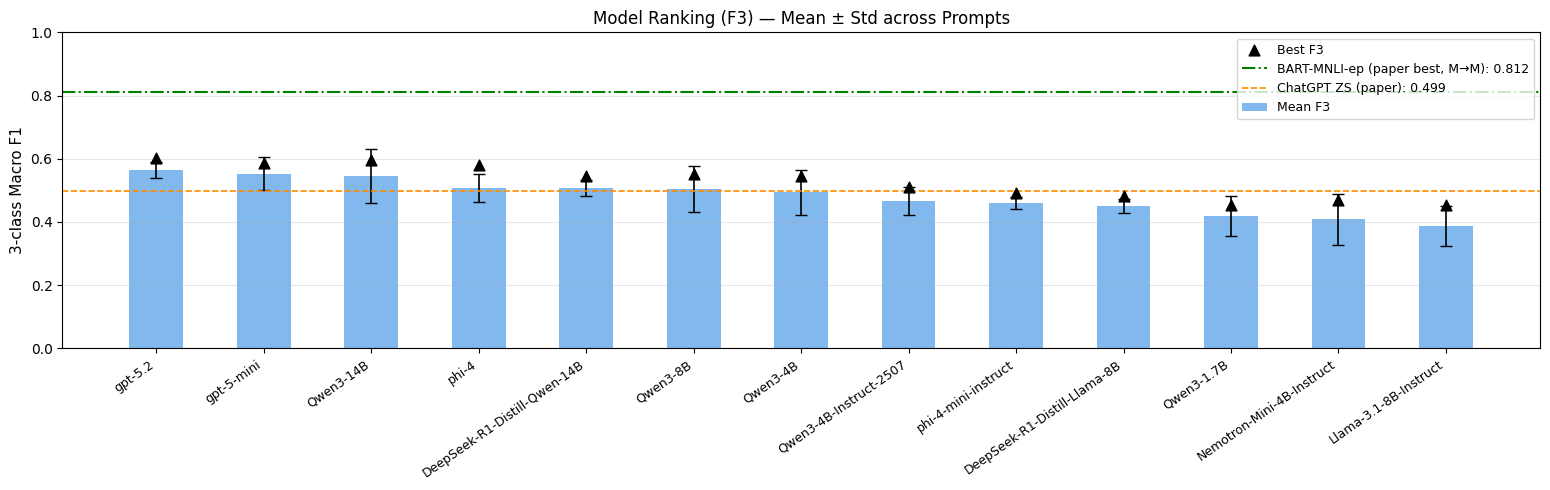


=== Ranking Table ===
                 model_short mean_f3 best_f3 std_f3 mean_f1_favor mean_f1_against mean_f1_none
                     gpt-5.2  0.5637  0.6034 0.0246        0.6378          0.6290       0.4242
                  gpt-5-mini  0.5533  0.5874 0.0512        0.6453          0.6753       0.3392
                   Qwen3-14B  0.5451  0.5949 0.0846        0.6167          0.5554       0.4631
                       phi-4  0.5074  0.5815 0.0441        0.5814          0.5699       0.3710
DeepSeek-R1-Distill-Qwen-14B  0.5073  0.5455 0.0250        0.5715          0.5339       0.4166
                    Qwen3-8B  0.5047  0.5532 0.0723        0.5875          0.5253       0.4014
                    Qwen3-4B  0.4933  0.5451 0.0714        0.6002          0.5535       0.3262
      Qwen3-4B-Instruct-2507  0.4675  0.5108 0.0441        0.5859          0.5432       0.2735
         phi-4-mini-instruct  0.4606  0.4907 0.0194        0.5562          0.5174       0.3082
DeepSeek-R1-Distill-Llama-8

In [272]:
ranking = (
    llm_df.groupby("model")
    .agg(
        mean_f3        =("3class_macro_f1", "mean"),
        best_f3        =("3class_macro_f1", "max"),
        std_f3         =("3class_macro_f1", "std"),
        mean_f1_favor  =("f_favor",         "mean"),
        mean_f1_against=("f_against",       "mean"),
        mean_f1_none   =("f_none",          "mean"),
    )
    .reset_index()
    .sort_values("mean_f3", ascending=False)
)
ranking["model_short"] = ranking["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)
ranking["mean_f3"]     = ranking["mean_f3"].map("{:.4f}".format)
ranking["best_f3"]     = ranking["best_f3"].map("{:.4f}".format)
ranking["std_f3"]      = ranking["std_f3"].map("{:.4f}".format)
ranking["mean_f1_favor"]   = ranking["mean_f1_favor"].map("{:.4f}".format)
ranking["mean_f1_against"] = ranking["mean_f1_against"].map("{:.4f}".format)
ranking["mean_f1_none"]    = ranking["mean_f1_none"].map("{:.4f}".format)

n = len(ranking)
x = np.arange(n)
mean_f3_num = ranking["mean_f3"].astype(float)
best_f3_num = ranking["best_f3"].astype(float)
std_f3_num  = ranking["std_f3"].astype(float)

fig, ax = plt.subplots(figsize=(max(12, n * 1.2), 5))
ax.bar(x, mean_f3_num, width=0.5, color="#4C9BE8", alpha=0.7, label="Mean F3")
ax.errorbar(x, mean_f3_num, yerr=std_f3_num,
            fmt="none", color="black", capsize=4, linewidth=1.2)
ax.scatter(x, best_f3_num, marker="^", s=60, color="black", zorder=5, label="Best F3")
ax.axhline(BEST_PAPER_F3, color="green", linestyle="-.", linewidth=1.5,
           label=f"BART-MNLI-ep (paper best, M→M): {BEST_PAPER_F3}")
ax.axhline(CHATGPT_F3, color="darkorange", linestyle="--", linewidth=1.2,
           label=f"ChatGPT ZS (paper): {CHATGPT_F3}")
ax.set_xticks(x)
ax.set_xticklabels(ranking["model_short"], rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("3-class Macro F1", fontsize=11)
ax.set_title("Model Ranking (F3) — Mean ± Std across Prompts", fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Ranking Table ===")
cols = ["model_short","mean_f3","best_f3","std_f3","mean_f1_favor","mean_f1_against","mean_f1_none"]
print(ranking[cols].to_string(index=False))

## Step 13: Prompt Sensitivity

**Table 13a** — per model: std F3, best/worst prompt, F3 range.
**Plot 13b** — F3 range per model (sorted by range descending).
**Table 13c** — per prompt: mean F3 across all models.

=== Table 13a: Per-model Prompt Sensitivity ===
                 model_short  std_f3  best_f3  worst_f3  range_f3                  best_prompt          worst_prompt
   Nemotron-Mini-4B-Instruct  0.0809   0.4690    0.1700    0.2990                      default task_definition_scale
                   Qwen3-14B  0.0846   0.5949    0.2967    0.2982                      default task_definition_scale
                    Qwen3-8B  0.0723   0.5532    0.2942    0.2590                      default task_definition_scale
                    Qwen3-4B  0.0714   0.5451    0.2884    0.2567                      default task_definition_scale
       Llama-3.1-8B-Instruct  0.0641   0.4539    0.2198    0.2341 default_no_label_definitions task_definition_scale
                  Qwen3-1.7B  0.0634   0.4540    0.2333    0.2207                          cot task_definition_scale
                  gpt-5-mini  0.0512   0.5874    0.4104    0.1770              task_definition task_definition_scale
      Qwen3-4B-I

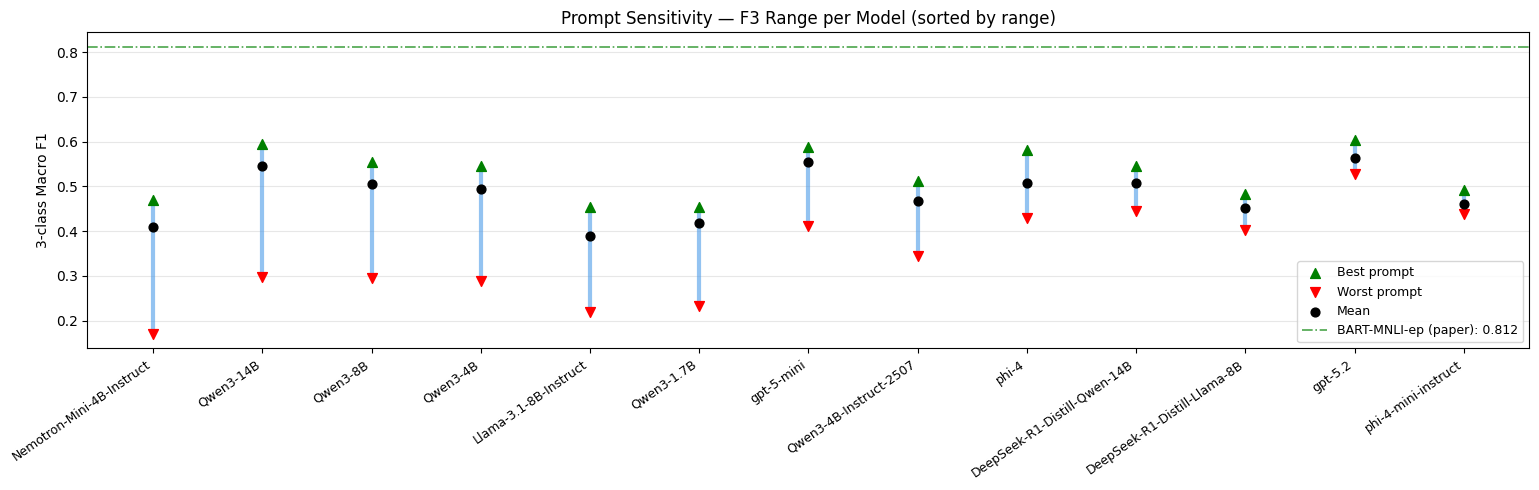


=== Table 13c: Per-prompt mean F3 across all models ===
                              mean_f3  std_f3  best_f3       group
prompt                                                            
default_no_label_definitions   0.4947  0.0464   0.5797   Zero-shot
default                        0.5271  0.0566   0.6034   Zero-shot
task_definition                0.5187  0.0589   0.6033   Zero-shot
question                       0.4732  0.0420   0.5346   Zero-shot
cot                            0.4942  0.0565   0.5802   Zero-shot
task_definition_scale          0.3484  0.1081   0.5272   Zero-shot
few_shot_3                     0.4884  0.0714   0.5821  Random ICL
few_shot_6                     0.4880  0.0648   0.5769  Random ICL
few_shot_9                     0.4901  0.0606   0.5748  Random ICL
few_shot_12                    0.4899  0.0575   0.5682  Random ICL
few_shot_15                    0.4916  0.0541   0.5681  Random ICL


In [273]:
ZERO_SHOT_PROMPTS  = ["default_no_label_definitions", "default", "task_definition",
                       "question", "cot", "task_definition_scale"]
RANDOM_ICL_PROMPTS = ["few_shot_3", "few_shot_6", "few_shot_9", "few_shot_12", "few_shot_15"]
PROMPT_GROUP = {**{p: "Zero-shot" for p in ZERO_SHOT_PROMPTS},
                **{p: "Random ICL" for p in RANDOM_ICL_PROMPTS}}

sens_rows = []
for model in _ordered_models(llm_df):
    mdf = llm_df[llm_df["model"] == model]
    sens_rows.append({
        "model":        model,
        "mean_f3":      mdf["3class_macro_f1"].mean(),
        "std_f3":       mdf["3class_macro_f1"].std(),
        "best_f3":      mdf["3class_macro_f1"].max(),
        "worst_f3":     mdf["3class_macro_f1"].min(),
        "range_f3":     mdf["3class_macro_f1"].max() - mdf["3class_macro_f1"].min(),
        "best_prompt":  mdf.loc[mdf["3class_macro_f1"].idxmax(), "prompt"],
        "worst_prompt": mdf.loc[mdf["3class_macro_f1"].idxmin(), "prompt"],
    })
sens_df = pd.DataFrame(sens_rows).sort_values("range_f3", ascending=False)
sens_df["model_short"] = sens_df["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)

print("=== Table 13a: Per-model Prompt Sensitivity ===")
cols_s = ["model_short", "std_f3", "best_f3", "worst_f3", "range_f3", "best_prompt", "worst_prompt"]
print(sens_df[cols_s].to_string(index=False, float_format="{:.4f}".format))

n = len(sens_df)
x = np.arange(n)
fig, ax = plt.subplots(figsize=(max(10, n * 1.2), 5))
ax.vlines(x, sens_df["worst_f3"], sens_df["best_f3"],
          color="#4C9BE8", linewidth=3, alpha=0.6)
ax.scatter(x, sens_df["best_f3"],  marker="^", color="green",  s=50, zorder=5, label="Best prompt")
ax.scatter(x, sens_df["worst_f3"], marker="v", color="red",    s=50, zorder=5, label="Worst prompt")
ax.scatter(x, sens_df["mean_f3"],  marker="o", color="black",  s=40, zorder=6, label="Mean")
ax.axhline(BEST_PAPER_F3, color="green", linestyle="-.", linewidth=1.2, alpha=0.7,
           label=f"BART-MNLI-ep (paper): {BEST_PAPER_F3}")
ax.set_xticks(x)
ax.set_xticklabels(sens_df["model_short"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("3-class Macro F1")
ax.set_title("Prompt Sensitivity — F3 Range per Model (sorted by range)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Table 13c: Per-prompt mean F3 across all models ===")
avail = [p for p in PROMPT_ORDER if p in llm_df["prompt"].unique()]
prom_tbl = (
    llm_df[llm_df["prompt"].isin(avail)]
    .groupby("prompt")["3class_macro_f1"]
    .agg(["mean", "std", "max"])
    .reindex(avail)
    .rename(columns={"mean": "mean_f3", "std": "std_f3", "max": "best_f3"})
)
prom_tbl["group"] = prom_tbl.index.map(PROMPT_GROUP)
print(prom_tbl.round(4).to_string())

## Step 14: F3 by Prompt Family — Grouped Bar Chart

Three families: **Label Defs** (zero-shot label variants), **Reasoning** (question / CoT / scale), **Random ICL** (3–15 shots).
Bar = mean F3 for that family per model. Horizontal lines = individual prompt F3. Red dashed = paper best.

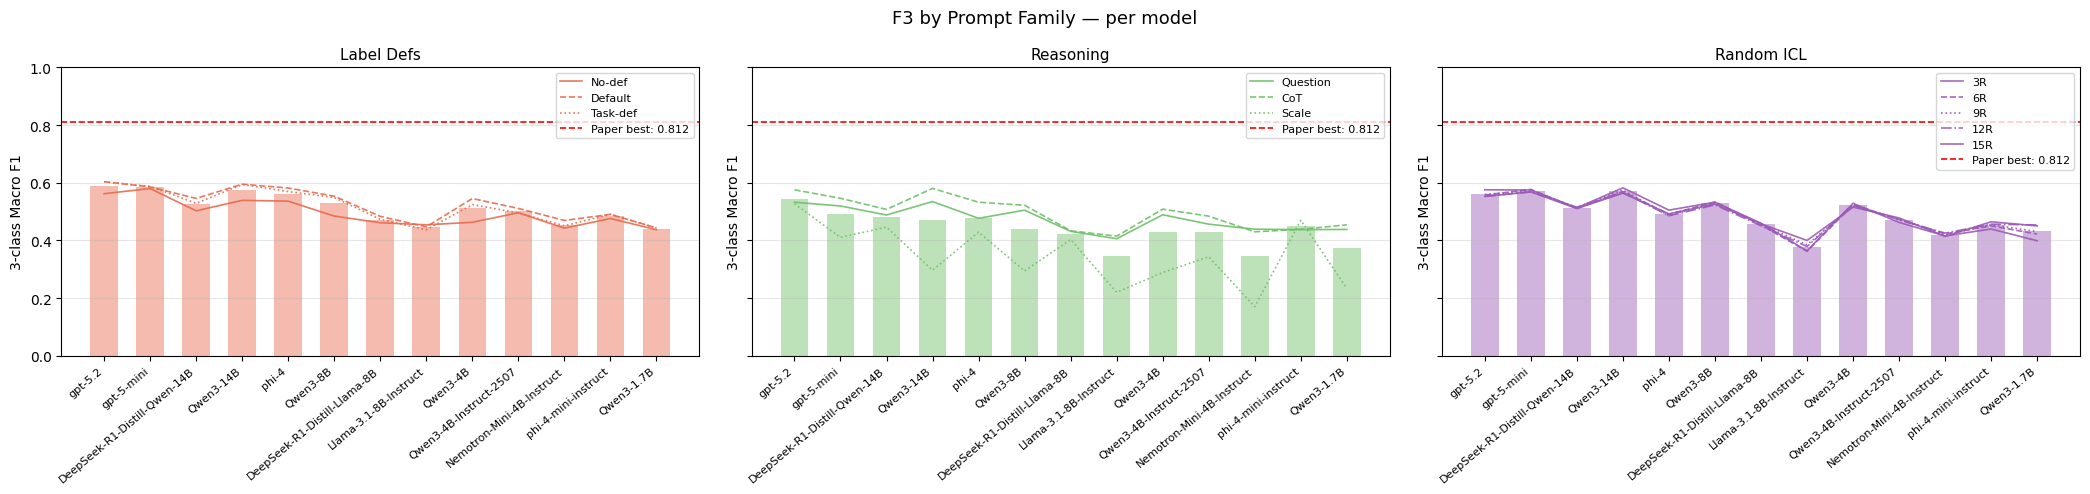

In [274]:
FAMILIES = OrderedDict([
    ("Label Defs", {
        "prompts": ["default_no_label_definitions", "default", "task_definition"],
        "labels":  ["No-def", "Default", "Task-def"],
        "color":   "#E8694C", "styles": ["-", "--", ":"],
    }),
    ("Reasoning", {
        "prompts": ["question", "cot", "task_definition_scale"],
        "labels":  ["Question", "CoT", "Scale"],
        "color":   "#6DBF67", "styles": ["-", "--", ":"],
    }),
    ("Random ICL", {
        "prompts": ["few_shot_3","few_shot_6","few_shot_9","few_shot_12","few_shot_15"],
        "labels":  ["3R","6R","9R","12R","15R"],
        "color":   "#9B59B6", "styles": ["-","--",":","-.","-"],
    }),
])

avail_models = _ordered_models(llm_df)
avail_model_labels = [m.split("/")[-1] if "/" in m else m for m in avail_models]
x = np.arange(len(avail_models))
bar_w = 0.6

fig, axes = plt.subplots(1, len(FAMILIES), figsize=(7 * len(FAMILIES), 5), sharey=True)
fig.suptitle("F3 by Prompt Family — per model", fontsize=13)

for ax, (fam_name, fam) in zip(axes, FAMILIES.items()):
    fam_prompts = [p for p in fam["prompts"] if p in llm_df["prompt"].unique()]
    if not fam_prompts:
        ax.set_title(fam_name)
        continue

    means = [llm_df[(llm_df["model"] == m) & (llm_df["prompt"].isin(fam_prompts))]["3class_macro_f1"].mean()
             for m in avail_models]
    ax.bar(x, means, width=bar_w, color=fam["color"], alpha=0.45)

    for pj, prompt in enumerate(fam_prompts):
        ys = []
        for xi, model in enumerate(avail_models):
            row = llm_df[(llm_df["model"] == model) & (llm_df["prompt"] == prompt)]
            ys.append(row["3class_macro_f1"].values[0] if len(row) else float("nan"))
        ax.plot(x, ys, color=fam["color"],
                linestyle=fam["styles"][pj % len(fam["styles"])],
                linewidth=1.2, alpha=0.9,
                label=fam["labels"][pj])

    ax.axhline(BEST_PAPER_F3, color="red", linestyle="--", linewidth=1.2,
               label=f"Paper best: {BEST_PAPER_F3}")
    ax.set_title(fam_name, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(avail_model_labels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("3-class Macro F1")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 15: Per-domain Macro F1 Analysis

8 EZStance domains: **CE** (Covid Epidemic), **WE** (World Events), **EdC** (Education & Culture),
**EnC** (Entertainment & Consumption), **S** (Sports), **R** (Rights), **EP** (Environmental Protection), **P** (Politics).

In [275]:
gold_mixed = pd.read_csv(GOLD_CSV)
gold_mixed["gold"] = gold_mixed["stance_label_original"].apply(canonicalize)
gold_mixed["id"]   = gold_mixed["id"].astype(str)

domain_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_7798"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue

    preds = pd.read_csv(csv_path)
    preds["pred"] = preds["predicted_stance"].apply(
        lambda x: canonicalize(x) if pd.notna(x) else None
    )
    preds["id"] = preds["doc_id"].astype(str)
    merged = preds[["id","pred"]].merge(gold_mixed[["id","gold","domain"]], on="id")
    merged = merged[merged["pred"].isin(CLASSES)]

    for domain in DOMAIN_ORDER:
        sub = merged[merged["domain"] == domain]
        if len(sub) == 0:
            continue
        _, _, f, _ = precision_recall_fscore_support(
            sub["gold"], sub["pred"], labels=CLASSES, average=None, zero_division=0
        )
        domain_rows.append({
            "model": model, "prompt": prompt, "domain": domain,
            "macro_f1": f.mean(), "f_favor": f[0], "f_against": f[1], "f_none": f[2],
        })

domain_df = pd.DataFrame(domain_rows)
print(f"Loaded {len(domain_df)} model×prompt×domain rows")
print("\nMean macro F1 per domain (across all model×prompt):")
print(domain_df.groupby("domain")["macro_f1"].mean().reindex(DOMAIN_ORDER).round(3).to_string())

Loaded 1144 model×prompt×domain rows

Mean macro F1 per domain (across all model×prompt):
domain
CE     0.480
WE     0.478
EdC    0.486
EnC    0.473
S      0.474
R      0.466
EP     0.489
P      0.473


### Chart: Per-domain Macro F1 — each model, mean across prompts

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_5452/1867072345.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_dom   = plt.cm.get_cmap("tab10", max(len(models_dom), 2))


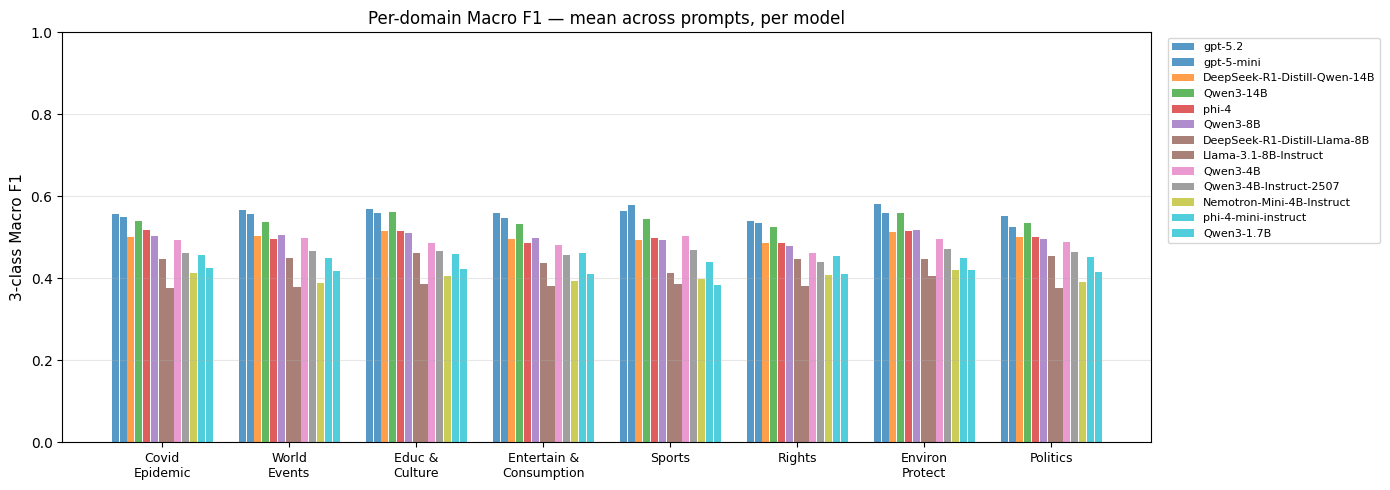

In [276]:
domain_mean = (
    domain_df.groupby(["model","domain"])["macro_f1"].mean().reset_index()
)
models_dom = _ordered_models(domain_df)
cmap_dom   = plt.cm.get_cmap("tab10", max(len(models_dom), 2))
x = np.arange(len(DOMAIN_ORDER))
bar_w_dom  = 0.8 / max(len(models_dom), 1)

fig, ax = plt.subplots(figsize=(14, 5))
for i, model in enumerate(models_dom):
    mdf = domain_mean[domain_mean["model"] == model].set_index("domain")
    y = [mdf.loc[d, "macro_f1"] if d in mdf.index else float("nan") for d in DOMAIN_ORDER]
    short  = model.split("/")[-1] if "/" in model else model
    offset = (i - len(models_dom)/2 + 0.5) * bar_w_dom
    ax.bar(x + offset, y, width=bar_w_dom * 0.9, color=cmap_dom(i), alpha=0.75, label=short)

ax.set_xticks(x)
ax.set_xticklabels([DOMAIN_NAMES.get(d, d) for d in DOMAIN_ORDER], fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("3-class Macro F1", fontsize=11)
ax.set_title("Per-domain Macro F1 — mean across prompts, per model", fontsize=12)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Per-domain per-class F1 — best prompt per model

Best prompt per model: {'DeepSeek-R1-Distill-Llama-8B': 'default', 'DeepSeek-R1-Distill-Qwen-14B': 'default', 'Llama-3.1-8B-Instruct': 'default_no_label_definitions', 'Nemotron-Mini-4B-Instruct': 'default', 'Qwen3-1.7B': 'cot', 'Qwen3-14B': 'default', 'Qwen3-4B-Instruct-2507': 'default', 'Qwen3-4B': 'default', 'Qwen3-8B': 'default', 'phi-4-mini-instruct': 'task_definition', 'phi-4': 'default', 'gpt-5-mini': 'task_definition', 'gpt-5.2': 'default'}


/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_5452/648867095.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_sel         = plt.cm.get_cmap("tab10", max(len(models_sel), 2))


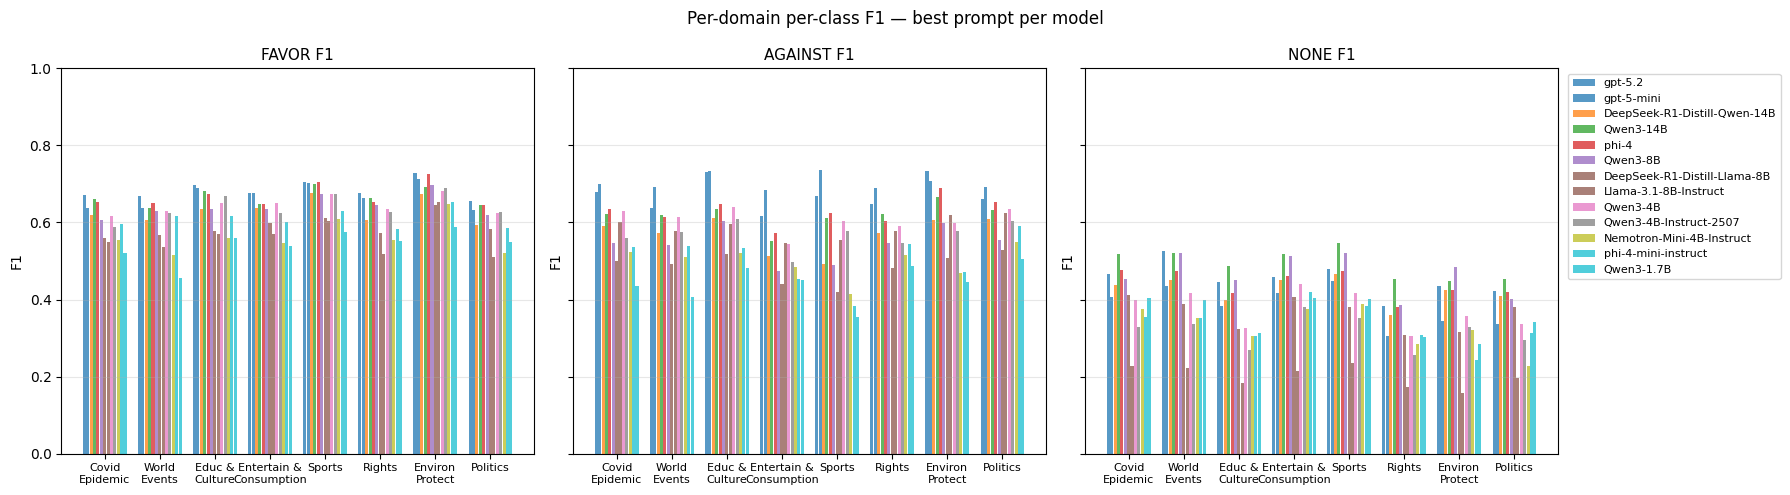

In [277]:
best_prompts_map = {
    m: llm_df.loc[llm_df[llm_df["model"] == m]["3class_macro_f1"].idxmax(), "prompt"]
    for m in llm_df["model"].unique()
}
print("Best prompt per model:", best_prompts_map)

selected = domain_df[domain_df.apply(
    lambda r: best_prompts_map.get(r["model"]) == r["prompt"], axis=1
)]
models_sel       = _ordered_models(selected)
model_labels_sel = [m.split("/")[-1] if "/" in m else m for m in models_sel]
cmap_sel         = plt.cm.get_cmap("tab10", max(len(models_sel), 2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle("Per-domain per-class F1 — best prompt per model", fontsize=12)

class_cols = [("f_favor","FAVOR"), ("f_against","AGAINST"), ("f_none","NONE")]
for col_idx, (cls_col, cls_name) in enumerate(class_cols):
    ax      = axes[col_idx]
    x       = np.arange(len(DOMAIN_ORDER))
    bar_w_s = 0.8 / max(len(models_sel), 1)
    for i, model in enumerate(models_sel):
        mdf = selected[selected["model"] == model].set_index("domain")
        y   = [mdf.loc[d, cls_col] if d in mdf.index else float("nan") for d in DOMAIN_ORDER]
        short  = model.split("/")[-1] if "/" in model else model
        offset = (i - len(models_sel)/2 + 0.5) * bar_w_s
        ax.bar(x + offset, y, width=bar_w_s * 0.9, color=cmap_sel(i), alpha=0.75, label=short)
    ax.set_xticks(x)
    ax.set_xticklabels([DOMAIN_NAMES.get(d, d) for d in DOMAIN_ORDER], fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(f"{cls_name} F1", fontsize=11)
    ax.set_ylabel("F1")
    ax.grid(axis="y", alpha=0.3)

axes[2].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Domain Ranking Table — which domains are hardest?

In [278]:
domain_ranking = (
    domain_df.groupby("domain")
    .agg(
        mean_f3       =("macro_f1",  "mean"),
        std_f3        =("macro_f1",  "std"),
        mean_f_favor  =("f_favor",   "mean"),
        mean_f_against=("f_against", "mean"),
        mean_f_none   =("f_none",    "mean"),
    )
    .reindex(DOMAIN_ORDER)
    .sort_values("mean_f3")
)
domain_ranking["domain_name"] = [
    DOMAIN_NAMES.get(d, d).replace("\n", " ") for d in domain_ranking.index
]
print("=== Domain Ranking Table (hardest → easiest) ===")
print(domain_ranking[
    ["domain_name","mean_f3","std_f3","mean_f_favor","mean_f_against","mean_f_none"]
].round(3).to_string())

=== Domain Ranking Table (hardest → easiest) ===
                    domain_name  mean_f3  std_f3  mean_f_favor  mean_f_against  mean_f_none
domain                                                                                     
R                        Rights    0.466   0.069         0.576           0.537        0.285
EnC     Entertain & Consumption    0.473   0.075         0.566           0.463        0.390
P                      Politics    0.473   0.076         0.550           0.560        0.310
S                        Sports    0.474   0.085         0.600           0.433        0.389
WE                 World Events    0.478   0.079         0.537           0.524        0.373
CE               Covid Epidemic    0.480   0.077         0.546           0.528        0.364
EdC              Educ & Culture    0.486   0.081         0.585           0.551        0.323
EP              Environ Protect    0.489   0.080         0.638           0.531        0.298


## Step 16: Per-domain Confusion Transition Heatmap

Same 6 transitions, broken out per domain. Values = mean transition rate across all prompts per model.
Reveals whether hedging (AGAINST→NONE) and agreeableness (FAVOR bias) are domain-conditioned.

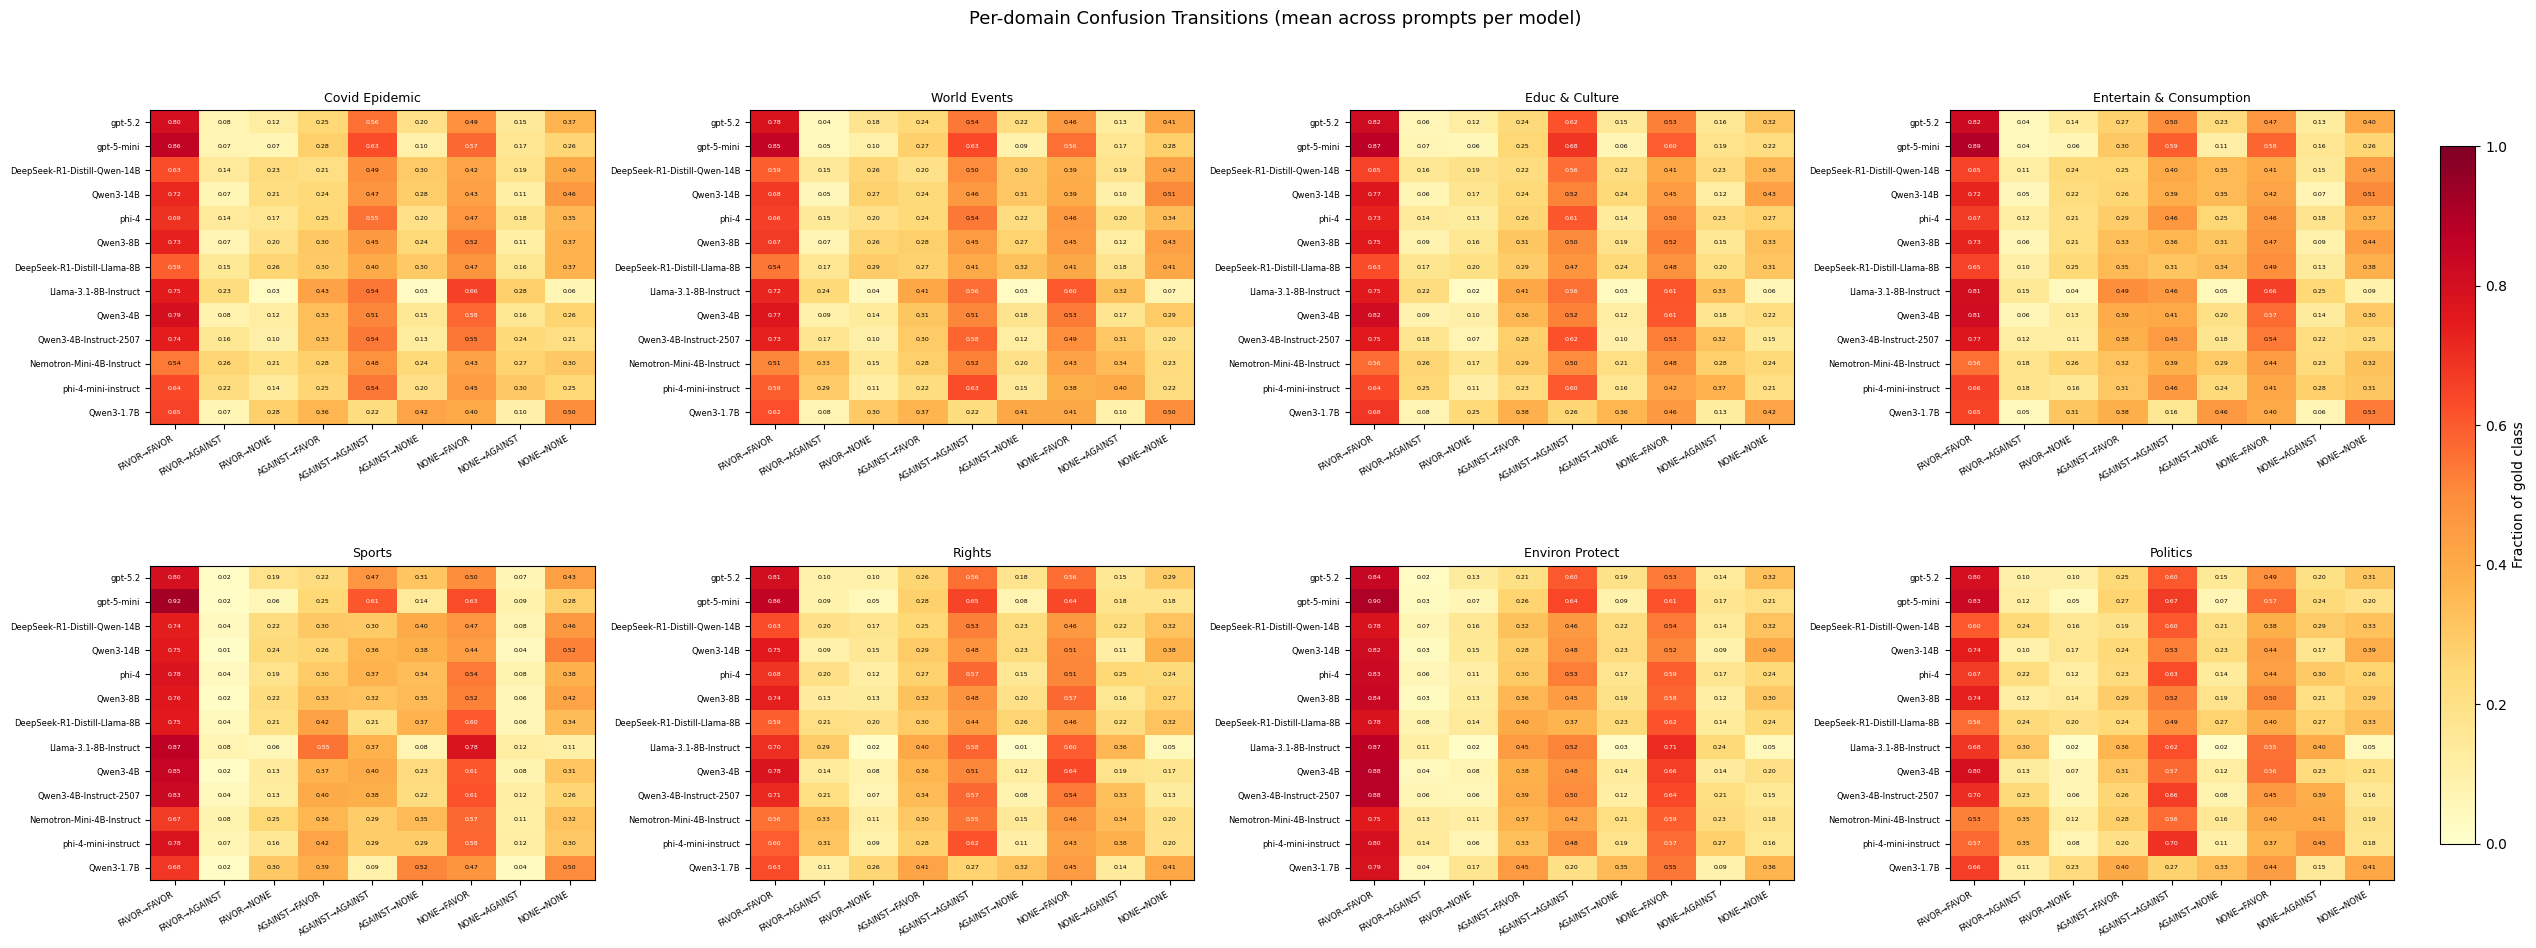

In [279]:
dom_cm_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_7798"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue

    preds = pd.read_csv(csv_path)
    preds["pred"] = preds["predicted_stance"].apply(
        lambda x: canonicalize(x) if pd.notna(x) else None
    )
    preds["id"] = preds["doc_id"].astype(str)
    merged = preds[["id","pred"]].merge(gold_mixed[["id","gold","domain"]], on="id")
    merged = merged[merged["pred"].isin(CLASSES) & merged["gold"].isin(CLASSES)]
    short = model.split("/")[-1] if "/" in model else model

    for domain in DOMAIN_ORDER:
        sub = merged[merged["domain"] == domain]
        if len(sub) < 10:
            continue
        cm      = confusion_matrix(sub["gold"], sub["pred"], labels=CLASSES).astype(float)
        row_sum = cm.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm, row_sum, where=row_sum > 0)

        row = {"model": model, "model_short": short, "prompt": prompt, "domain": domain}
        for ri, tc in enumerate(CLASSES):
            for ci, pc in enumerate(CLASSES):
                row[f"{tc}→{pc}"] = cm_norm[ri, ci]
        dom_cm_rows.append(row)

dom_cm_df = pd.DataFrame(dom_cm_rows)

model_order_hm = _ordered_models(llm_df)

fig, axes = plt.subplots(2, 4, figsize=(30, 10),
                         gridspec_kw={"hspace": 0.45, "wspace": 0.35})
fig.suptitle("Per-domain Confusion Transitions (mean across prompts per model)", fontsize=13)

for di, domain in enumerate(DOMAIN_ORDER):
    ax  = axes[di // 4][di % 4]
    sub = dom_cm_df[dom_cm_df["domain"] == domain]
    if len(sub) == 0:
        ax.set_title(DOMAIN_NAMES.get(domain, domain).replace("\n", " "))
        ax.axis("off")
        continue

    mean_trans = (
        sub.groupby("model")[KEY_TRANS].mean()
        .reindex([m for m in model_order_hm if m in sub["model"].unique()])
    )
    hmap     = mean_trans.values
    row_lbls = [m.split("/")[-1] if "/" in m else m for m in mean_trans.index]

    im = ax.imshow(hmap, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1.0)
    ax.set_xticks(range(len(KEY_TRANS)))
    ax.set_xticklabels(KEY_TRANS, fontsize=6, rotation=30, ha="right")
    ax.set_yticks(range(len(row_lbls)))
    ax.set_yticklabels(row_lbls, fontsize=6)
    ax.set_title(DOMAIN_NAMES.get(domain, domain).replace("\n", " "), fontsize=9)

    for r in range(hmap.shape[0]):
        for c in range(hmap.shape[1]):
            val = hmap[r, c]
            ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                    fontsize=4.5, color="black" if val < 0.55 else "white")

plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.015, pad=0.02,
             label="Fraction of gold class")
plt.show()